<a href="https://colab.research.google.com/github/SergeiVKalinin/camm_hackathon/blob/k4my4r/docs/day_10_27032026/CAMM_hackaton_10_Image_Restoration_Kalinin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CAMM Hackathon #10: STEM Image Restoration

STEM image credits: Austin Houston


In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
!gdown https://drive.google.com/file/d/14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs/view?usp=drive_link --fuzzy

Downloading...
From: https://drive.google.com/uc?id=14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs
To: /content/graphene_2.h5
100% 17.1M/17.1M [00:00<00:00, 54.7MB/s]


In [3]:
!gdown https://drive.google.com/file/d/1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN/view?usp=drive_link --fuzzy

Downloading...
From: https://drive.google.com/uc?id=1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN
To: /content/HAADF_21.h5
100% 4.53M/4.53M [00:00<00:00, 176MB/s]


In [4]:
#@title h5 load
def save_dict_to_hdf5(file_path, data_dict):
    with h5py.File(file_path, 'w') as f:
        _recursively_save(f, data_dict)

def _recursively_save(group, data):
    if isinstance(data, dict):
        for key, value in data.items():
            subgroup = group.create_group(str(key))
            _recursively_save(subgroup, value)

    elif isinstance(data, list):
        # Turn list into group with numerical keys
        for i, item in enumerate(data):
            subgroup = group.create_group(str(i))
            _recursively_save(subgroup, item)

    elif isinstance(data, np.ndarray):
        if data.dtype == object:
            # convert each element to string (json)
            data_as_str = np.array([json.dumps(x) for x in data], dtype='S256')
            group.create_dataset('value', data=data_as_str)
        else:
            group.create_dataset('value', data=data)

    elif isinstance(data, (int, float, np.int_, np.float_)):
        group.create_dataset('value', data=data)

    elif data is None:
        group.attrs['value'] = 'None'

    else:
        # Fallback: convert unknown object to JSON string
        group.create_dataset('value', data=json.dumps(data))


def load_hdf5_to_dict(file_path):
    with h5py.File(file_path, "r") as f:
        return _load_item(f)



def _load_item(obj):
    """
    Load any HDF5 object (Group or Dataset) and reconstruct Python object.
    """
    # ---------------------------------------------------------
    # CASE 1 — HDF5 GROUP  (recursive dict or list)
    # ---------------------------------------------------------
    if isinstance(obj, h5py.Group):
        keys = list(obj.keys())

        # Empty group → return None or empty dict
        if len(keys) == 0 and "value" not in obj.attrs:
            return {}

        # Detect list: all keys are integers
        if all(k.isdigit() for k in keys):
            lst = []
            for k in sorted(keys, key=lambda x: int(x)):
                lst.append(_load_item(obj[k]))
            return lst

        # Regular dictionary
        out = {}
        for k in keys:
            out[k] = _load_item(obj[k])

        # Special case: group representing None
        if "value" in obj.attrs and obj.attrs["value"] == "None":
            return None

        return out

    # ---------------------------------------------------------
    # CASE 2 — HDF5 DATASET  (arrays / scalars / strings)
    # ---------------------------------------------------------
    elif isinstance(obj, h5py.Dataset):
        data = obj[()]

        # Scalar
        if np.isscalar(data):
            return data

        # Byte strings → JSON or text
        if isinstance(data, (bytes, np.bytes_)):
            try:
                return json.loads(data.decode())
            except:
                return data.decode()

        # Array of byte strings
        if data.dtype.kind == "S":
            try:
                return [json.loads(x.decode()) for x in data]
            except:
                return [x.decode() for x in data]

        # Normal numpy array
        return data

    # ---------------------------------------------------------
    # CASE 3 — Attributes marking None
    # ---------------------------------------------------------
    else:
        raise ValueError("Unknown HDF5 object type:", obj)


def get_arr(runs, key):
    """
    Extract numpy array from runs[key], automatically handling nested {'value': array}.
    """
    val = runs[key]
    if isinstance(val, dict) and "value" in val:
        return np.asarray(val["value"])
    return np.asarray(val)



In [5]:
#@title masking functions
from scipy.ndimage import binary_dilation
from skimage.draw import line as draw_line

def mask_below_line(im, row=None, frac=0.6, above=True):
    """
    Mask all pixels below (or above) a horizontal threshold row.

    Parameters
    ----------
    im : 2D array
    row   : int, absolute row index. Defaults to frac * H.
    frac  : float, fraction of height for the cut if row is None.
    above : bool, if True mask everything above the line instead.

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    H, W = im.shape
    if row is None:
        row = int(frac * H)
    mask = np.zeros((H, W), dtype=bool)
    if above:
        mask[:row, :] = True
    else:
        mask[row:, :] = True
    return mask

def mask_lakes(im, n_lakes=10, size_range=(10, 220), aspect_range=(0.5, 4.0),
               roughness=0.8, n_harmonics=34, seed=None):
    """
    Lake regions with ragged / torn borders, arranged in a loose cluster.

    The border is a polar curve whose radius is modulated by a sum of random
    sinusoids, producing irregular, non-repeating jagged edges.

    Parameters
    ----------
    im : 2D array
    n_lakes      : number of lakes
    size_range   : (min, max) semi-major axis in pixels
    aspect_range : (min, max) aspect ratio (semi-major / semi-minor)
    roughness    : 0 = smooth ellipse, 1 = very jagged (good range: 0.2–0.6)
    n_harmonics  : number of sinusoidal harmonics added to the border
    seed         : RNG seed

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    rng = np.random.default_rng(seed)
    H, W = im.shape
    mask = np.zeros((H, W), dtype=bool)

    # loose cluster centre
    cy_c = rng.integers(H // 4, 3 * H // 4)
    cx_c = rng.integers(W // 4, 3 * W // 4)
    spread = max(H, W) // 4

    yy, xx = np.mgrid[:H, :W]

    for _ in range(n_lakes):
        cy = int(np.clip(rng.normal(cy_c, spread), 0, H - 1))
        cx = int(np.clip(rng.normal(cx_c, spread), 0, W - 1))
        a = rng.integers(*size_range)           # semi-major
        aspect = rng.uniform(*aspect_range)
        b = max(1, int(a / aspect))             # semi-minor
        angle = rng.uniform(0, np.pi)

        # rotate coordinates
        dy = yy - cy
        dx = xx - cx
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        u = cos_a * dx + sin_a * dy             # along major axis
        v = -sin_a * dx + cos_a * dy            # along minor axis

        # polar angle of every pixel relative to lake centre
        theta = np.arctan2(v, u)

        # ragged radius envelope: 1 + sum of random harmonics
        freqs = rng.integers(2, n_harmonics + 2, size=n_harmonics)
        amps  = rng.uniform(0, roughness / n_harmonics, size=n_harmonics)
        phases = rng.uniform(0, 2 * np.pi, size=n_harmonics)
        envelope = 1.0 + sum(
            amp * np.sin(freq * theta + phase)
            for amp, freq, phase in zip(amps, freqs, phases)
        )

        # pixel is inside if its normalised ellipse distance < ragged envelope
        dist = np.sqrt((u / a) ** 2 + (v / b) ** 2)
        mask |= dist <= envelope

    return ~mask

def mask_lines(im, n_lines=80, thickness=4, orientation="horizontal", seed=None):
    """
    Thin random straight lines across the image (horizontal, vertical, or diagonal).

    Parameters
    ----------
    im : 2D array
    n_lines     : number of lines
    thickness   : line width in pixels (via dilation)
    orientation : "horizontal" | "vertical" | "diagonal" | "mixed"
    seed        : RNG seed

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    rng = np.random.default_rng(seed)
    H, W = im.shape
    mask = np.zeros((H, W), dtype=bool)

    orientations = ["horizontal", "vertical", "diagonal"]

    for _ in range(n_lines):
        if orientation == "mixed":
            ort = rng.choice(orientations)
        else:
            ort = orientation

        if ort == "horizontal":
            r = rng.integers(0, H)
            mask[r, :] = True
        elif ort == "vertical":
            c = rng.integers(0, W)
            mask[:, c] = True
        else:  # diagonal
            r0, c0 = rng.integers(0, H), rng.integers(0, W)
            r1, c1 = rng.integers(0, H), rng.integers(0, W)
            rr, cc = draw_line(r0, c0, r1, c1)
            valid = (rr >= 0) & (rr < H) & (cc >= 0) & (cc < W)
            mask[rr[valid], cc[valid]] = True

    if thickness > 1:
        struct = np.ones((thickness, thickness), dtype=bool)
        mask = binary_dilation(mask, structure=struct)

    return ~mask

def mask_small_blobs(im, n_blobs=300, size_range=(1, 24), seed=None):
    """
    Many tiny blobs simulating dead-pixel clusters or dust on the detector.

    Parameters
    ----------
    im      : 2D array
    n_blobs    : number of small blobs
    size_range : (min_r, max_r) radius in pixels
    seed       : RNG seed

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    rng = np.random.default_rng(seed)
    H, W = im.shape
    mask = np.zeros((H, W), dtype=bool)

    yy, xx = np.ogrid[:H, :W]

    for _ in range(n_blobs):
        cy = rng.integers(0, H)
        cx = rng.integers(0, W)
        r = rng.integers(*size_range)
        mask |= (yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2

    return ~mask

In [6]:
data = load_hdf5_to_dict('/content/graphene_2.h5')
data_more = load_hdf5_to_dict('/content/HAADF_21.h5')

im0 = data['Measurement_000']['Channel_000']['HAADF']['HAADF'][:1000, :1000]
im1 = data['Measurement_001']['Channel_000']['HAADF']['HAADF'][:1000, :1000]
im2 = data['Measurement_001']['Channel_000']['HAADF']['HAADF'][:1000, -1000:]
im3 = data_more['Measurement_000']['Channel_000']['HAADF']['HAADF']

ims = [im0, im1, im2, im3]

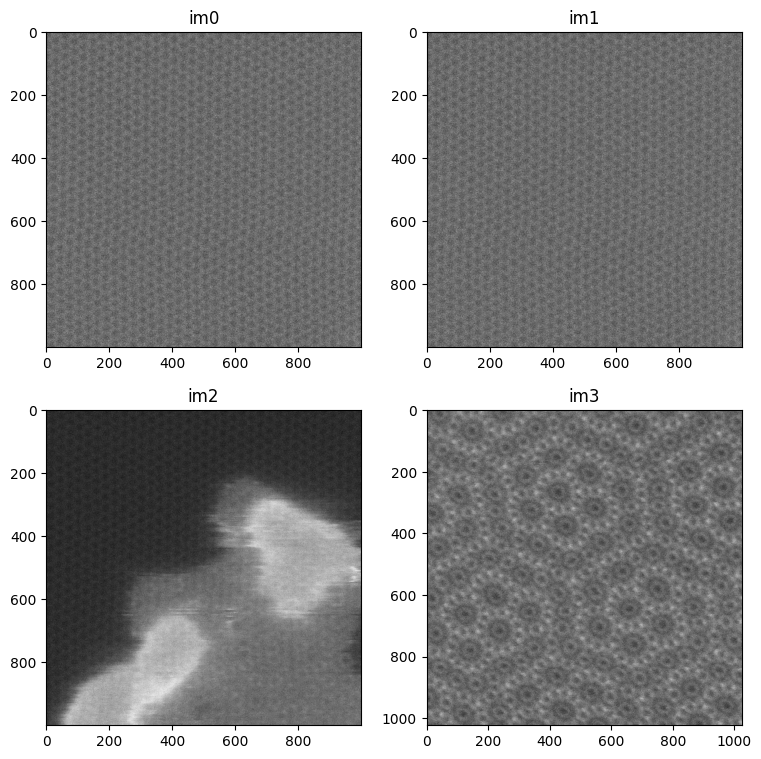

In [7]:
fig, axes = plt.subplots(2,2, figsize=(9,9))

ax = axes.flatten()

for i, _ in enumerate(ax):
  _.imshow(ims[i], cmap='gray')
  _.set_title(f'im{i}')

Text(0.5, 1.0, 'mask_small_blobs()')

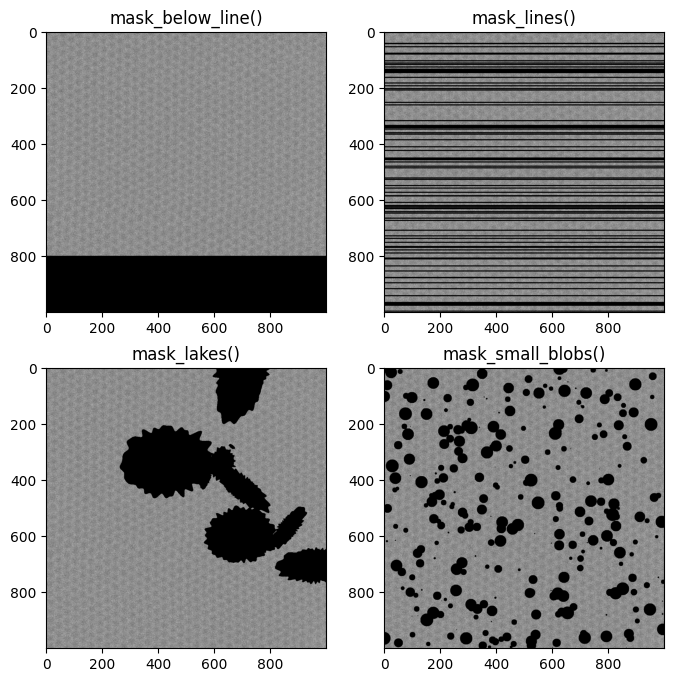

In [8]:
fig, ax = plt.subplots(2,2, figsize=(8,8))


ax[0,0].imshow(mask_below_line(im0, frac=0.8)*im0, cmap='gray')
ax[0,0].set_title('mask_below_line()')

ax[0,1].imshow(mask_lines(im0)*im0, cmap='gray')
ax[0,1].set_title('mask_lines()')

ax[1,0].imshow(mask_lakes(im0)*im0, cmap='gray')
ax[1,0].set_title('mask_lakes()')

ax[1,1].imshow(mask_small_blobs(im0)*im0, cmap='gray')
ax[1,1].set_title('mask_small_blobs()')


# Given a 2D microscopy intensity array and a binary loss mask, reconstruct missing regions and estimate prediction uncertainty

(1000, 1000) (1000, 1000)
59105 8137


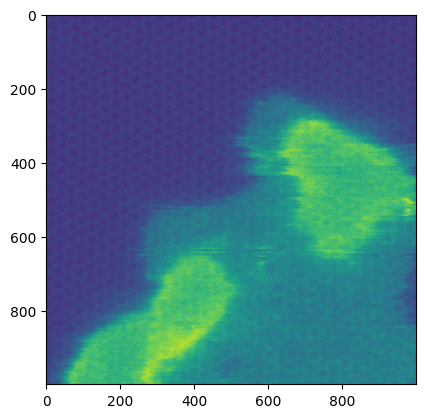

In [9]:
plt.imshow(im2)
print(im2.shape, mask_small_blobs(im2).shape)
print(im2.max(), im2.min())

In [10]:
def normalize_image(image):
  min_val = image.min()
  max_val = image.max()
  if max_val == min_val:
    return np.zeros_like(image)
  normalized_image = (image - min_val) / (max_val - min_val)
  return normalized_image

int64


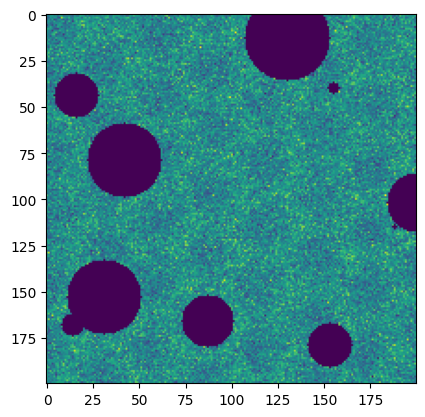

In [11]:
im3n = normalize_image(im1)
mask_missing = mask_small_blobs(im3n)[:200, :200]
image_occlude = mask_missing*im3n[:200, 0:200]
plt.imshow(image_occlude)
#mask_missing = mask_small_blobs(im2)[:100, :100]
mask_missing = 1 - mask_missing #given our defintition of what is missing
print(mask_missing.dtype)

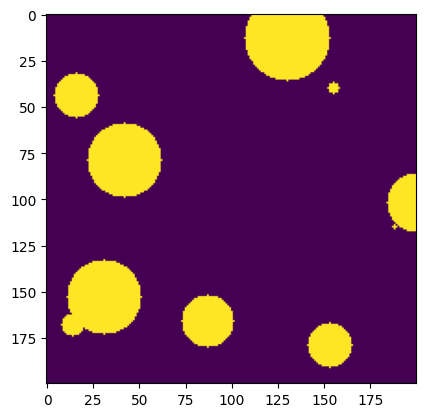

In [12]:
plt.imshow(mask_missing)

# Local dictionary reconstruction

# 1. Patchwise Bayesian Sparse Coding with a Learned Dictionary

In this example, we reconstruct an image with missing or corrupted regions by assuming that each local image patch can be represented as a sparse combination of atoms from a learned dictionary.

The patch model is

$$
x_r = D \alpha_r
$$

and the observed patch is

$$
y_r = M_r x_r + \varepsilon_r = M_r D \alpha_r + \varepsilon_r
$$

where $x_r$ is the latent clean patch, $y_r$ is the observed patch, $M_r$ is the patch-level mask selecting valid pixels, $D$ is the learned dictionary, and $\alpha_r$ is a sparse coefficient vector.

The dictionary is learned from visible patches in the image, so the algorithm uses the image itself as a source of prior knowledge about plausible local structures. The Bayesian part comes from placing a sparse prior on the coefficients $\alpha_r$, implemented here through ARD-style Bayesian regression. This produces not only a posterior-mean reconstruction of each patch, but also a posterior covariance over the patch coefficients, which can be propagated back into patch-level uncertainty in image space.

Overlapping reconstructed patches are then aggregated into a full-image mean and uncertainty map using weighted overlap-add. In this sense, the algorithm does not produce just one inpainted image: it produces a posterior estimate of the latent clean image, together with an uncertainty map showing where the reconstruction is well constrained and where it is ambiguous.

This approach is especially useful when the image contains repeated local motifs, short-range texture, edges, or local defect structures. It does not assume a global lattice or long-range periodicity, so it is well suited for problems where local morphology matters more than reciprocal-space structure. Its main limitation is that global periodic backgrounds are represented only indirectly, through many local patches, which can be inefficient when the image contains strong long-range order.

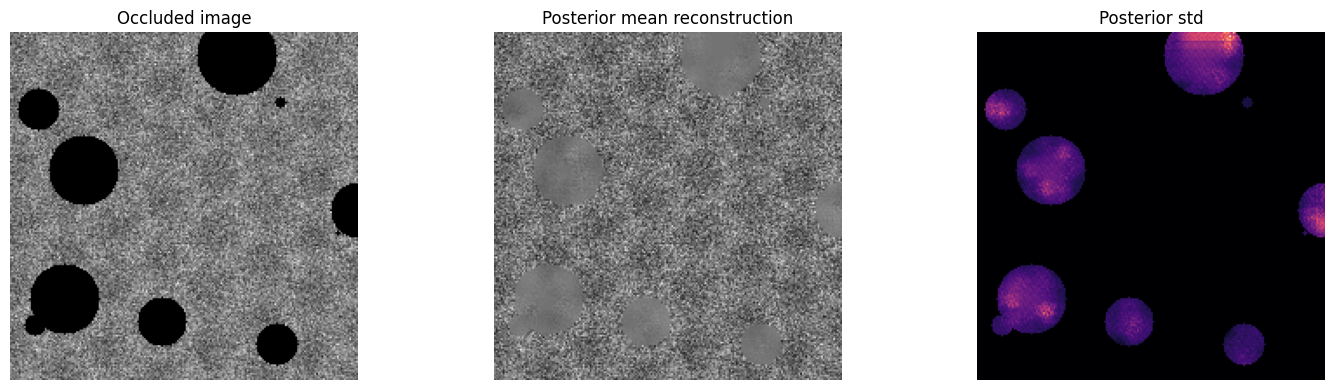

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import MiniBatchDictionaryLearning
from sklearn.linear_model import ARDRegression


# ============================================================
# Utilities
# ============================================================

def _patch_starts(length, patch_size, stride):
    starts = list(range(0, max(length - patch_size + 1, 1), stride))
    last = length - patch_size
    if last < 0:
        raise ValueError("patch_size must be <= image dimensions")
    if len(starts) == 0 or starts[-1] != last:
        starts.append(last)
    return starts


def _iter_patch_coords(H, W, patch_size, stride):
    rows = _patch_starts(H, patch_size, stride)
    cols = _patch_starts(W, patch_size, stride)
    for i in rows:
        for j in cols:
            yield i, j


def _soft_window(patch_size):
    """
    Nonzero smooth weighting window for overlap-add.
    """
    if patch_size < 3:
        return np.ones((patch_size, patch_size), dtype=float)
    w1 = np.hanning(patch_size)
    if np.allclose(w1, 0):
        w1 = np.ones_like(w1)
    else:
        w1 = 0.25 + 0.75 * (w1 / w1.max())  # keep edges nonzero
    w2 = np.outer(w1, w1)
    return w2


def _normalize_observed(image, valid_mask):
    obs = image[valid_mask]
    mu = float(np.mean(obs))
    sigma = float(np.std(obs))
    if sigma < 1e-8:
        sigma = 1.0
    image_n = (image - mu) / sigma
    return image_n, mu, sigma


def _collect_training_patches(
    image_norm,
    valid_mask,
    patch_size=8,
    train_stride=2,
    max_train_patches=20000,
    min_valid_frac=0.98,
    random_state=0
):
    """
    Collect mostly visible patches for dictionary learning.
    Missing entries in near-complete patches are mean-imputed (0 in normalized units).
    """
    H, W = image_norm.shape
    patches = []

    for i, j in _iter_patch_coords(H, W, patch_size, train_stride):
        patch = image_norm[i:i+patch_size, j:j+patch_size]
        maskp = valid_mask[i:i+patch_size, j:j+patch_size]
        frac = maskp.mean()

        if frac >= min_valid_frac:
            p = patch.copy()
            if not maskp.all():
                # normalized mean is approximately 0
                p[~maskp] = 0.0
            patches.append(p.ravel())

    if len(patches) == 0:
        raise RuntimeError(
            "No training patches found. Lower min_valid_frac or provide more visible data."
        )

    patches = np.asarray(patches, dtype=float)

    rng = np.random.default_rng(random_state)
    if len(patches) > max_train_patches:
        idx = rng.choice(len(patches), size=max_train_patches, replace=False)
        patches = patches[idx]

    return patches


def learn_dictionary_from_visible_patches(
    image_norm,
    valid_mask,
    patch_size=8,
    n_components=128,
    train_stride=2,
    max_train_patches=20000,
    min_valid_frac=0.98,
    dict_alpha=1.0,
    batch_size=256,
    n_iter=500,
    random_state=0
):
    """
    Learn an overcomplete patch dictionary from mostly visible patches.
    Returns D with shape (patch_dim, n_atoms).
    """
    patches = _collect_training_patches(
        image_norm=image_norm,
        valid_mask=valid_mask,
        patch_size=patch_size,
        train_stride=train_stride,
        max_train_patches=max_train_patches,
        min_valid_frac=min_valid_frac,
        random_state=random_state
    )

    learner = MiniBatchDictionaryLearning(
        n_components=n_components,
        alpha=dict_alpha,
        batch_size=batch_size,
        max_iter=n_iter,
        random_state=random_state,
        verbose=False
    )
    learner.fit(patches)

    # sklearn stores dictionary atoms as rows: (n_atoms, patch_dim)
    D = learner.components_.T  # (patch_dim, n_atoms)

    # Add a DC atom explicitly
    dc = np.ones((D.shape[0], 1), dtype=float)
    dc /= np.linalg.norm(dc) + 1e-12
    D = np.concatenate([dc, D], axis=1)

    # Normalize atoms
    D /= (np.linalg.norm(D, axis=0, keepdims=True) + 1e-12)

    return D


# ============================================================
# Bayesian sparse coding on one patch
# ============================================================

def _gaussian_posterior_fallback(A, y, D_full, noise_std=0.05, prior_var=1.0):
    """
    Fallback linear-Gaussian posterior if ARD fails.
    A: observed design matrix, shape (n_obs, n_atoms)
    y: observed pixel values, shape (n_obs,)
    D_full: full patch dictionary, shape (patch_dim, n_atoms)
    """
    K = A.shape[1]
    noise_var = noise_std ** 2

    # alpha ~ N(0, prior_var * I)
    precision = (A.T @ A) / noise_var + np.eye(K) / prior_var
    Sigma = np.linalg.inv(precision)
    mu = Sigma @ (A.T @ y) / noise_var

    x_mu = D_full @ mu
    x_var = np.einsum("ij,jk,ik->i", D_full, Sigma, D_full)

    return x_mu, np.maximum(x_var, 0.0), mu, Sigma


def bayesian_patch_reconstruct(
    patch_norm,
    valid_patch_mask,
    D,
    noise_std=0.05,
    ard_max_iter=300,
    ard_tol=1e-4
):
    """
    Bayesian sparse coding for one patch:
        y_obs = D_obs alpha + eps
    using ARDRegression.

    Returns:
        patch_mean (flat)
        patch_var  (flat)
    """
    ps = patch_norm.shape[0]
    p = ps * ps

    y_full = patch_norm.ravel()
    obs_idx = valid_patch_mask.ravel()
    y_obs = y_full[obs_idx]

    D_obs = D[obs_idx, :]     # rows = observed pixels
    D_full = D                # rows = all pixels

    n_obs = len(y_obs)

    # No observed pixels in the patch:
    # prior mean = 0, prior covariance approx from atoms with unit coefficient variance
    if n_obs == 0:
        prior_var = np.sum(D_full**2, axis=1)
        prior_mean = np.zeros(p, dtype=float)
        return prior_mean, prior_var

    # Very few observed pixels: use simple linear-Gaussian fallback
    if n_obs < 4:
        x_mu, x_var, _, _ = _gaussian_posterior_fallback(
            A=D_obs, y=y_obs, D_full=D_full, noise_std=noise_std, prior_var=1.0
        )
        return x_mu, x_var

    try:
        try:
            ard = ARDRegression(
                fit_intercept=False,
                max_iter=ard_max_iter,
                tol=ard_tol
            )
        except TypeError:
            # compatibility with older sklearn
            ard = ARDRegression(
                fit_intercept=False,
                n_iter=ard_max_iter,
                tol=ard_tol
            )

        ard.fit(D_obs, y_obs)

        coef = ard.coef_
        Sigma = ard.sigma_

        x_mu = D_full @ coef
        x_var = np.einsum("ij,jk,ik->i", D_full, Sigma, D_full)
        x_var = np.maximum(x_var, 0.0)

        return x_mu, x_var

    except Exception:
        x_mu, x_var, _, _ = _gaussian_posterior_fallback(
            A=D_obs, y=y_obs, D_full=D_full, noise_std=noise_std, prior_var=1.0
        )
        return x_mu, x_var


# ============================================================
# Full image inpainting
# ============================================================

def bayesian_dictionary_inpaint(
    image_occlude,
    mask_missing=None,
    patch_size=8,
    stride=1,
    train_stride=10,
    n_components=10,
    dict_alpha=1.0,
    max_train_patches=20000,
    min_train_valid_frac=0.98,
    noise_std=0.05,
    ard_max_iter=300,
    ard_tol=1e-4,
    random_state=0,
    clip_to_observed_range=False
):
    """
    Bayesian dictionary-based inpainting with uncertainty.

    Parameters
    ----------
    image_occlude : 2D ndarray
        Grayscale image with missing pixels as NaN, unless mask_missing is supplied.
    mask_missing : 2D bool ndarray, optional
        True where pixels are missing.
    patch_size : int
        Patch size, e.g. 8, 12, or 16.
    stride : int
        Patch stride for inpainting.
    train_stride : int
        Patch stride for dictionary learning.
    n_components : int
        Number of learned atoms (before adding DC atom).
    dict_alpha : float
        Sparsity/regularization strength for dictionary learning.
    max_train_patches : int
        Max number of training patches.
    min_train_valid_frac : float
        Minimum visible fraction of a patch to use for dictionary learning.
    noise_std : float
        Noise std in normalized units for fallback Bayesian solver.
    clip_to_observed_range : bool
        Clip output to min/max of observed pixels.

    Returns
    -------
    recon : 2D ndarray
        Posterior-mean reconstruction.
    unc : 2D ndarray
        Posterior std map.
    D : 2D ndarray
        Learned dictionary, shape (patch_dim, n_atoms).
    """
    image = np.asarray(image_occlude, dtype=float)
    if image.ndim != 2:
        raise ValueError("This implementation expects a 2D grayscale image.")

    H, W = image.shape

    if mask_missing is None:
        mask_missing = ~np.isfinite(image)
        if not np.any(mask_missing):
            raise ValueError(
                "No NaNs found. Either encode missing pixels as NaN or pass mask_missing explicitly."
            )
    else:
        mask_missing = np.asarray(mask_missing, dtype=bool)
        if mask_missing.shape != image.shape:
            raise ValueError("mask_missing must have the same shape as image_occlude.")

    valid_mask = ~mask_missing

    # Temporary fill for normalization only
    image_fill = image.copy()
    observed_mean = np.nanmean(image_fill[valid_mask])
    image_fill[mask_missing] = observed_mean

    image_norm, obs_mu, obs_sigma = _normalize_observed(image_fill, valid_mask)

    # Learn dictionary from visible patches
    D = learn_dictionary_from_visible_patches(
        image_norm=image_norm,
        valid_mask=valid_mask,
        patch_size=patch_size,
        n_components=n_components,
        train_stride=train_stride,
        max_train_patches=max_train_patches,
        min_valid_frac=min_train_valid_frac,
        dict_alpha=dict_alpha,
        random_state=random_state
    )

    win = _soft_window(patch_size)

    # Accumulators only where missing pixels will be estimated
    mean_num = np.zeros_like(image_norm, dtype=float)
    var_num = np.zeros_like(image_norm, dtype=float)
    weight_den = np.zeros_like(image_norm, dtype=float)

    # Only process patches that intersect the missing region
    for i, j in _iter_patch_coords(H, W, patch_size, stride):
        miss_patch = mask_missing[i:i+patch_size, j:j+patch_size]
        if not np.any(miss_patch):
            continue

        patch = image_norm[i:i+patch_size, j:j+patch_size]
        valid_patch = valid_mask[i:i+patch_size, j:j+patch_size]

        patch_mu_flat, patch_var_flat = bayesian_patch_reconstruct(
            patch_norm=patch,
            valid_patch_mask=valid_patch,
            D=D,
            noise_std=noise_std,
            ard_max_iter=ard_max_iter,
            ard_tol=ard_tol
        )

        patch_mu = patch_mu_flat.reshape(patch_size, patch_size)
        patch_var = patch_var_flat.reshape(patch_size, patch_size)

        mean_num[i:i+patch_size, j:j+patch_size] += win * patch_mu
        var_num[i:i+patch_size, j:j+patch_size] += (win**2) * patch_var
        weight_den[i:i+patch_size, j:j+patch_size] += win

    recon_norm = image_norm.copy()
    unc_norm = np.zeros_like(image_norm, dtype=float)

    miss_idx = mask_missing & (weight_den > 0)
    recon_norm[miss_idx] = mean_num[miss_idx] / weight_den[miss_idx]
    unc_norm[miss_idx] = np.sqrt(var_num[miss_idx]) / np.maximum(weight_den[miss_idx], 1e-12)

    # If some missing pixels received no estimate, fall back to normalized mean=0 with large uncertainty
    miss_no_est = mask_missing & (weight_den == 0)
    recon_norm[miss_no_est] = 0.0
    unc_norm[miss_no_est] = 1.0

    recon = recon_norm * obs_sigma + obs_mu
    unc = unc_norm * obs_sigma

    # Enforce exact agreement on observed pixels
    recon[valid_mask] = image_fill[valid_mask]
    unc[valid_mask] = 0.0

    if clip_to_observed_range:
        vmin = np.nanmin(image_fill[valid_mask])
        vmax = np.nanmax(image_fill[valid_mask])
        recon = np.clip(recon, vmin, vmax)

    return recon, unc, D


# ============================================================
# Example usage
# ============================================================


# Case 1: missing pixels in image_occlude are encoded as np.nan
recon, unc, D = bayesian_dictionary_inpaint(
    image_occlude,
    mask_missing=mask_missing,          # infer from NaNs
    patch_size=20,
    stride=5,
    train_stride=5,
    n_components=24,
    dict_alpha=1.0,
    max_train_patches=1500,
    min_train_valid_frac=0.98,
    noise_std=0.05,
    random_state=0,
    clip_to_observed_range=False
)


# If your missing region is not NaN-based, do this instead:
# mask_missing = ...
#recon, unc, D = bayesian_dictionary_inpaint(image_occlude, mask_missing=mask_missing, ...)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_occlude, cmap="gray")
plt.title("Occluded image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(recon, cmap="gray")
plt.title("Posterior mean reconstruction")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(unc, cmap="magma")
plt.title("Posterior std")
plt.axis("off")

plt.tight_layout()
plt.show()

Potential action items:
- explore the learned functions
- make benchmarks

# Fourier based sparse reconstruction

# 2. Global Fourier Bayesian Sparse Reconstruction

In this example, the image is represented as a sparse combination of a small number of global Fourier modes.

The reconstruction model is

$$
x = \Phi \beta
$$

and the observed pixels satisfy

$$
y_{\mathrm{obs}} = \Phi_{\mathrm{obs}} \beta + \varepsilon
$$

where $\Phi$ is a real-valued Fourier basis constructed from selected frequencies, and $\beta$ is the vector of Fourier coefficients. The observed pixels constrain the coefficient posterior, and Bayesian sparse regression is then used to infer which Fourier modes are truly needed to explain the data.

A major advantage of this formulation is that it provides direct access to the posterior distribution over the Fourier coefficients,

$$
\beta \mid y_{\mathrm{obs}} \sim \mathcal{N}(\mu_\beta, \Sigma_\beta)
$$

so that we can compute both the posterior-mean reconstruction and the uncertainty in image space. We can also sample from this posterior to generate multiple plausible reconstructions, which is particularly useful when masked regions are large or structurally ambiguous.

This method is best suited for images with strong periodic or quasi-periodic content, such as crystalline lattices, repeated stripes, or long-range ordered textures. In that regime, the image can often be described compactly by a relatively small number of frequencies, and the posterior over those frequencies is highly interpretable.

Its weakness is that localized defects, sharp boundaries, or strongly nonstationary structures are not represented efficiently. A local defect may require many Fourier modes, and the resulting uncertainty is global rather than spatially localized. For that reason, the Fourier model is most useful when the dominant physics is encoded in global periodic structure.

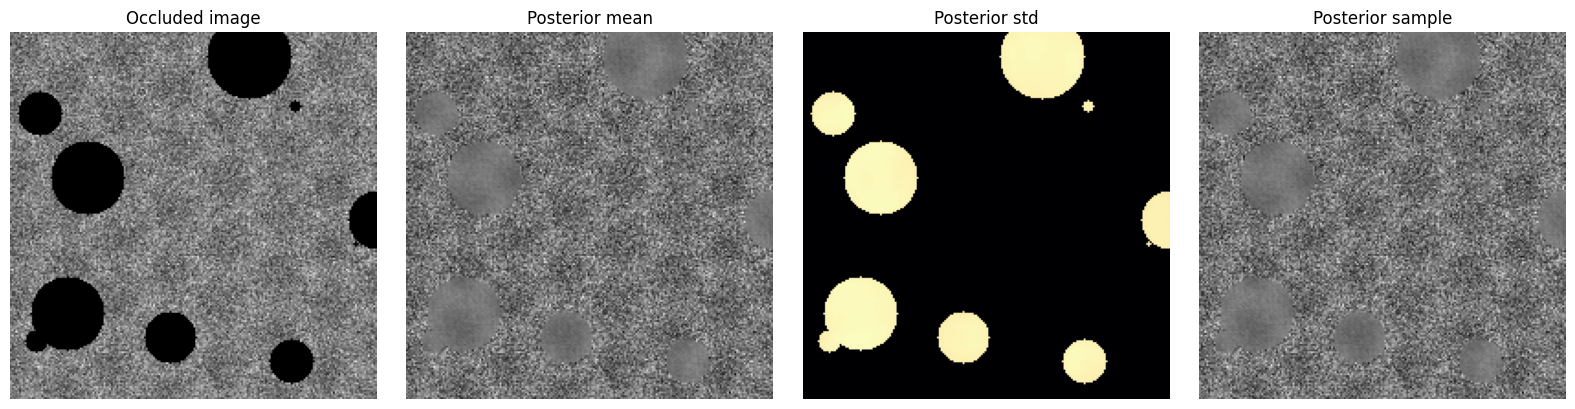

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ARDRegression


# ============================================================
# Utilities
# ============================================================

def _normalize_observed(image, valid_mask):
    obs = image[valid_mask]
    mu = float(np.mean(obs))
    sigma = float(np.std(obs))
    if sigma < 1e-8:
        sigma = 1.0
    image_n = (image - mu) / sigma
    return image_n, mu, sigma


def _gaussian_posterior_fallback(A, y, Phi_full, noise_std=0.05, prior_var=1.0):
    """
    Simple linear-Gaussian fallback:
        beta ~ N(0, prior_var I)
        y = A beta + eps, eps ~ N(0, noise_std^2 I)
    """
    K = A.shape[1]
    noise_var = noise_std ** 2

    precision = (A.T @ A) / noise_var + np.eye(K) / prior_var
    Sigma = np.linalg.inv(precision)
    mu = Sigma @ (A.T @ y) / noise_var

    x_mu = Phi_full @ mu
    x_var = np.einsum("ij,jk,ik->i", Phi_full, Sigma, Phi_full)
    x_var = np.maximum(x_var, 0.0)

    return x_mu, x_var, mu, Sigma


# ============================================================
# Frequency selection
# ============================================================

def select_candidate_frequencies(
    image_norm,
    valid_mask,
    max_freqs=64,
    known_peak_coords=None,
    use_observed_fft=True
):
    """
    Select candidate Fourier frequencies from the zero-filled observed image.

    Frequencies are returned in rfft2 indexing:
        (ky_idx, kx_idx)
    where:
        ky_idx in [0, H-1]
        kx_idx in [0, W//2]

    Parameters
    ----------
    image_norm : 2D ndarray
        Normalized image.
    valid_mask : 2D bool ndarray
        True where pixels are observed.
    max_freqs : int
        Number of FFT-derived frequency locations to keep (excluding forced peaks).
    known_peak_coords : list of tuples, optional
        User-specified frequencies to force into the model, e.g.
        [(ky1, kx1), (ky2, kx2), ...]
        in rfft indexing.
    use_observed_fft : bool
        If True, compute FFT on zero-filled observed image.
    """
    H, W = image_norm.shape

    if use_observed_fft:
        x0 = np.zeros_like(image_norm)
        x0[valid_mask] = image_norm[valid_mask]
    else:
        x0 = image_norm.copy()

    spec = np.fft.rfft2(x0)
    mag = np.abs(spec)

    # Remove DC from automatic selection
    mag[0, 0] = 0.0

    # Flatten and get top frequencies
    flat_idx = np.argsort(mag.ravel())[::-1]
    freq_list = []

    # Forced prior peaks first
    if known_peak_coords is not None:
        for f in known_peak_coords:
            ky, kx = int(f[0]), int(f[1])
            if 0 <= ky < H and 0 <= kx <= W // 2:
                if (ky, kx) not in freq_list and not (ky == 0 and kx == 0):
                    freq_list.append((ky, kx))

    for idx in flat_idx:
        ky, kx = np.unravel_index(idx, mag.shape)
        if (ky, kx) == (0, 0):
            continue
        if (ky, kx) not in freq_list:
            freq_list.append((ky, kx))
        if len(freq_list) >= (len(known_peak_coords) if known_peak_coords else 0) + max_freqs:
            break

    return freq_list


# ============================================================
# Fourier dictionary
# ============================================================

def build_real_fourier_dictionary(H, W, freq_list, include_dc=True):
    """
    Build a real-valued Fourier design matrix Phi of shape (H*W, K),
    using cosine/sine atoms corresponding to rfft2 frequencies.

    Returns
    -------
    Phi : ndarray, shape (H*W, K)
    atom_labels : list of tuples
        Labels like ("dc", 0, 0), ("cos", ky_signed, kx), ("sin", ky_signed, kx)
    """
    yy, xx = np.meshgrid(np.arange(H), np.arange(W), indexing="ij")
    yy = yy.ravel().astype(float)
    xx = xx.ravel().astype(float)

    atoms = []
    labels = []

    if include_dc:
        dc = np.ones(H * W, dtype=float)
        dc /= np.linalg.norm(dc) + 1e-12
        atoms.append(dc)
        labels.append(("dc", 0, 0))

    for ky_idx, kx_idx in freq_list:
        # Convert FFT row index to signed vertical frequency
        ky_signed = ky_idx if ky_idx <= H // 2 else ky_idx - H

        phase = 2.0 * np.pi * (ky_signed * yy / H + kx_idx * xx / W)

        c = np.cos(phase)
        c_norm = np.linalg.norm(c)
        if c_norm > 1e-10:
            atoms.append(c / c_norm)
            labels.append(("cos", ky_signed, kx_idx))

        s = np.sin(phase)
        s_norm = np.linalg.norm(s)
        # Some sine atoms are identically zero on the sampled grid
        if s_norm > 1e-10:
            atoms.append(s / s_norm)
            labels.append(("sin", ky_signed, kx_idx))

    Phi = np.column_stack(atoms)
    return Phi, labels


# ============================================================
# Main Fourier Bayesian inpainting
# ============================================================

def bayesian_fourier_inpaint(
    image_occlude,
    mask_missing=None,
    max_freqs=8,
    known_peak_coords=None,
    noise_std=0.05,
    ard_max_iter=500,
    ard_tol=1e-4,
    clip_to_observed_range=False,
    return_full_design=True
):
    """
    Global Fourier-sparse Bayesian inpainting.

    Model:
        x = Phi beta
        y_obs = Phi_obs beta + eps
    with ARD prior on beta.

    Parameters
    ----------
    image_occlude : 2D ndarray
        Grayscale image with missing pixels as NaN, unless mask_missing supplied.
    mask_missing : 2D bool ndarray, optional
        True where pixels are missing.
    max_freqs : int
        Number of FFT-derived candidate frequencies to include.
    known_peak_coords : list of tuples, optional
        Frequencies to force into the model in rfft indexing.
        Good place to encode prior knowledge (e.g. known Bragg peaks).
    noise_std : float
        Noise std in normalized units for fallback Gaussian model.
    clip_to_observed_range : bool
        Clip reconstruction to min/max of observed values.
    return_full_design : bool
        If True, store Phi_full in returned info for posterior sampling.

    Returns
    -------
    recon : 2D ndarray
        Posterior mean reconstruction.
    unc : 2D ndarray
        Posterior standard deviation map.
    info : dict
        Additional posterior information for inspection or sampling.
    """
    image = np.asarray(image_occlude, dtype=float)
    if image.ndim != 2:
        raise ValueError("This implementation expects a 2D grayscale image.")

    H, W = image.shape

    if mask_missing is None:
        mask_missing = ~np.isfinite(image)
        if not np.any(mask_missing):
            raise ValueError(
                "No NaNs found. Either encode missing pixels as NaN or pass mask_missing explicitly."
            )
    else:
        mask_missing = np.asarray(mask_missing, dtype=bool)
        if mask_missing.shape != image.shape:
            raise ValueError("mask_missing must have the same shape as image_occlude.")

    valid_mask = ~mask_missing

    # Temporary fill only for normalization / FFT candidate search
    image_fill = image.copy()
    obs_mean = np.nanmean(image_fill[valid_mask])
    image_fill[mask_missing] = obs_mean

    image_norm, obs_mu, obs_sigma = _normalize_observed(image_fill, valid_mask)

    # Candidate frequencies
    freq_list = select_candidate_frequencies(
        image_norm=image_norm,
        valid_mask=valid_mask,
        max_freqs=max_freqs,
        known_peak_coords=known_peak_coords,
        use_observed_fft=True
    )

    # Build global Fourier design matrix
    Phi_full, atom_labels = build_real_fourier_dictionary(
        H=H, W=W, freq_list=freq_list, include_dc=True
    )

    y_full = image_norm.ravel()
    obs_idx = valid_mask.ravel()
    y_obs = y_full[obs_idx]
    Phi_obs = Phi_full[obs_idx, :]

    # Fit ARD Bayesian regression
    try:
        try:
            ard = ARDRegression(
                fit_intercept=False,
                max_iter=ard_max_iter,
                tol=ard_tol
            )
        except TypeError:
            # compatibility with older sklearn
            ard = ARDRegression(
                fit_intercept=False,
                n_iter=ard_max_iter,
                tol=ard_tol
            )

        ard.fit(Phi_obs, y_obs)

        beta_mean = ard.coef_
        beta_cov = ard.sigma_

        x_mean_norm = Phi_full @ beta_mean
        x_var_norm = np.einsum("ij,jk,ik->i", Phi_full, beta_cov, Phi_full)
        x_var_norm = np.maximum(x_var_norm, 0.0)

    except Exception:
        x_mean_norm, x_var_norm, beta_mean, beta_cov = _gaussian_posterior_fallback(
            A=Phi_obs,
            y=y_obs,
            Phi_full=Phi_full,
            noise_std=noise_std,
            prior_var=1.0
        )

    recon = x_mean_norm.reshape(H, W) * obs_sigma + obs_mu
    unc = np.sqrt(x_var_norm.reshape(H, W)) * obs_sigma

    # Enforce exact agreement on observed pixels
    recon[valid_mask] = image_fill[valid_mask]
    unc[valid_mask] = 0.0

    if clip_to_observed_range:
        vmin = np.nanmin(image_fill[valid_mask])
        vmax = np.nanmax(image_fill[valid_mask])
        recon = np.clip(recon, vmin, vmax)

    info = {
        "freq_list_rfft": freq_list,
        "atom_labels": atom_labels,
        "beta_mean": beta_mean,
        "beta_cov": beta_cov,
        "obs_mu": obs_mu,
        "obs_sigma": obs_sigma,
        "mask_missing": mask_missing,
        "valid_mask": valid_mask,
        "image_shape": (H, W),
    }

    if return_full_design:
        info["Phi_full"] = Phi_full

    return recon, unc, info


# ============================================================
# Posterior sampling
# ============================================================

def sample_fourier_posterior(info, n_samples=16, random_state=0, enforce_observed=None):
    """
    Draw posterior samples of the full inpainted image from the coefficient posterior.

    Parameters
    ----------
    info : dict
        Output of bayesian_fourier_inpaint(...).
    n_samples : int
        Number of samples.
    random_state : int
        RNG seed.
    enforce_observed : 2D ndarray, optional
        If supplied, observed pixels are overwritten with the original observed values.

    Returns
    -------
    samples : ndarray, shape (n_samples, H, W)
    """
    if "Phi_full" not in info:
        raise ValueError("Phi_full not stored in info. Run with return_full_design=True.")

    rng = np.random.default_rng(random_state)

    beta_mean = info["beta_mean"]
    beta_cov = info["beta_cov"]
    Phi_full = info["Phi_full"]
    H, W = info["image_shape"]
    obs_mu = info["obs_mu"]
    obs_sigma = info["obs_sigma"]

    beta_samples = rng.multivariate_normal(beta_mean, beta_cov, size=n_samples)
    x_samples_norm = beta_samples @ Phi_full.T
    x_samples = x_samples_norm.reshape(n_samples, H, W) * obs_sigma + obs_mu

    if enforce_observed is not None:
        valid_mask = info["valid_mask"]
        for s in range(n_samples):
            x_samples[s][valid_mask] = enforce_observed[valid_mask]

    return x_samples


# ============================================================
# Example usage
# ============================================================

# Case 1: missing pixels encoded as NaN
recon, unc, info = bayesian_fourier_inpaint(
    image_occlude,
    mask_missing=mask_missing,
    max_freqs=120,
    known_peak_coords=None,   # e.g. [(ky1, kx1), (ky2, kx2)] if you know them
    noise_std=0.05,
    clip_to_observed_range=False,
    return_full_design=True
)

samples = sample_fourier_posterior(
    info,
    n_samples=8,
    random_state=0,
    enforce_observed=np.asarray(image_occlude, dtype=float)
)

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(image_occlude, cmap="gray")
plt.title("Occluded image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(recon, cmap="gray")
plt.title("Posterior mean")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(unc, cmap="magma")
plt.title("Posterior std")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(samples[0], cmap="gray")
plt.title("Posterior sample")
plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
mu_beta = info["beta_mean"]
Sigma_beta = info["beta_cov"]

print(type(mu_beta), mu_beta.shape)
print(type(Sigma_beta), Sigma_beta.shape)

<class 'numpy.ndarray'> (241,)
<class 'numpy.ndarray'> (241, 241)


0.0030518876942217483 -0.0002452738074024438


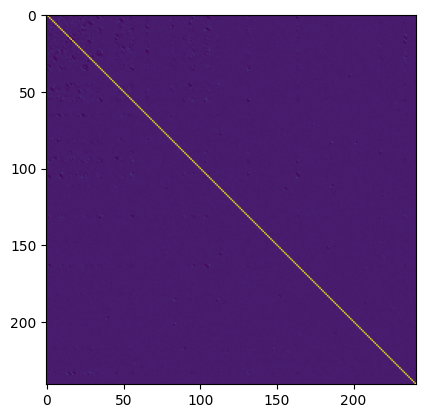

In [16]:
plt.imshow(Sigma_beta)
print(Sigma_beta.max(), Sigma_beta.min())

In [17]:
atom_labels = info["atom_labels"]

for k, (label, coeff) in enumerate(zip(atom_labels, mu_beta)):
    print(k, label, coeff)

0 ('dc', 0, 0) -0.32322623996667793
1 ('cos', np.int64(0), np.int64(7)) -22.27539050527437
2 ('sin', np.int64(0), np.int64(7)) -17.98046591348716
3 ('cos', np.int64(6), np.int64(3)) -9.959337193611612
4 ('sin', np.int64(6), np.int64(3)) -21.336782820309395
5 ('cos', np.int64(-6), np.int64(4)) -14.18835820089285
6 ('sin', np.int64(-6), np.int64(4)) 13.016149389720166
7 ('cos', np.int64(6), np.int64(4)) 5.293532259732792
8 ('sin', np.int64(6), np.int64(4)) 7.969870155603954
9 ('cos', np.int64(1), np.int64(7)) 2.295231000308582
10 ('sin', np.int64(1), np.int64(7)) 6.4975152107921295
11 ('cos', np.int64(6), np.int64(10)) -0.009619102704311065
12 ('sin', np.int64(6), np.int64(10)) 7.046794910279025
13 ('cos', np.int64(-6), np.int64(3)) 4.622407036698893
14 ('sin', np.int64(-6), np.int64(3)) -4.983500759824074
15 ('cos', np.int64(-6), np.int64(5)) -6.760643276934326
16 ('sin', np.int64(-6), np.int64(5)) 2.972358426528848
17 ('cos', np.int64(-5), np.int64(4)) 6.0538670329833915
18 ('sin', np.

# Fourier+Dictionary

# 3. Hybrid Fourier + Local Dictionary Reconstruction

In this example, we combine two complementary representations of the image.

The hybrid model is

$$
x \approx \Phi \beta + z_{\mathrm{local}}
$$

with the local residual represented as

$$
z_{\mathrm{local}} \approx \sum_r R_r^T D \alpha_r
$$

The first term, $\Phi \beta$, represents the global periodic or long-range structured background using a sparse Fourier model. The second term captures local residual structure using a learned patch dictionary. In other words, the Fourier block explains what is globally coherent across the image, while the dictionary block explains local departures such as defects, edges, interfaces, or other patch-scale structures.

The algorithm alternates between these two updates. First, given the current local estimate, it fits the Fourier background to the residual image. Then, after subtracting the Fourier mean, it reconstructs the remaining local residual patch by patch using Bayesian sparse coding. This produces a decomposition of the image into a global structured component and a local corrective component.

The returned objects include the Fourier coefficient posterior, patchwise local posteriors, the combined reconstruction, and an approximate uncertainty map obtained by combining the global and local variances. This makes it possible to inspect not only the final image, but also which part of the reconstruction is explained by long-range periodicity and which part is explained by localized corrections.

This hybrid model is often the most useful practical compromise for microscopy and materials images, where the data contain both long-range order and local defect physics. It is more expressive than pure Fourier and more efficient than pure dictionary coding when a lattice is present. Its limitation is that it still treats the Fourier part as globally coherent, so extended translational defects such as antiphase boundaries are represented only indirectly, through the local residual.

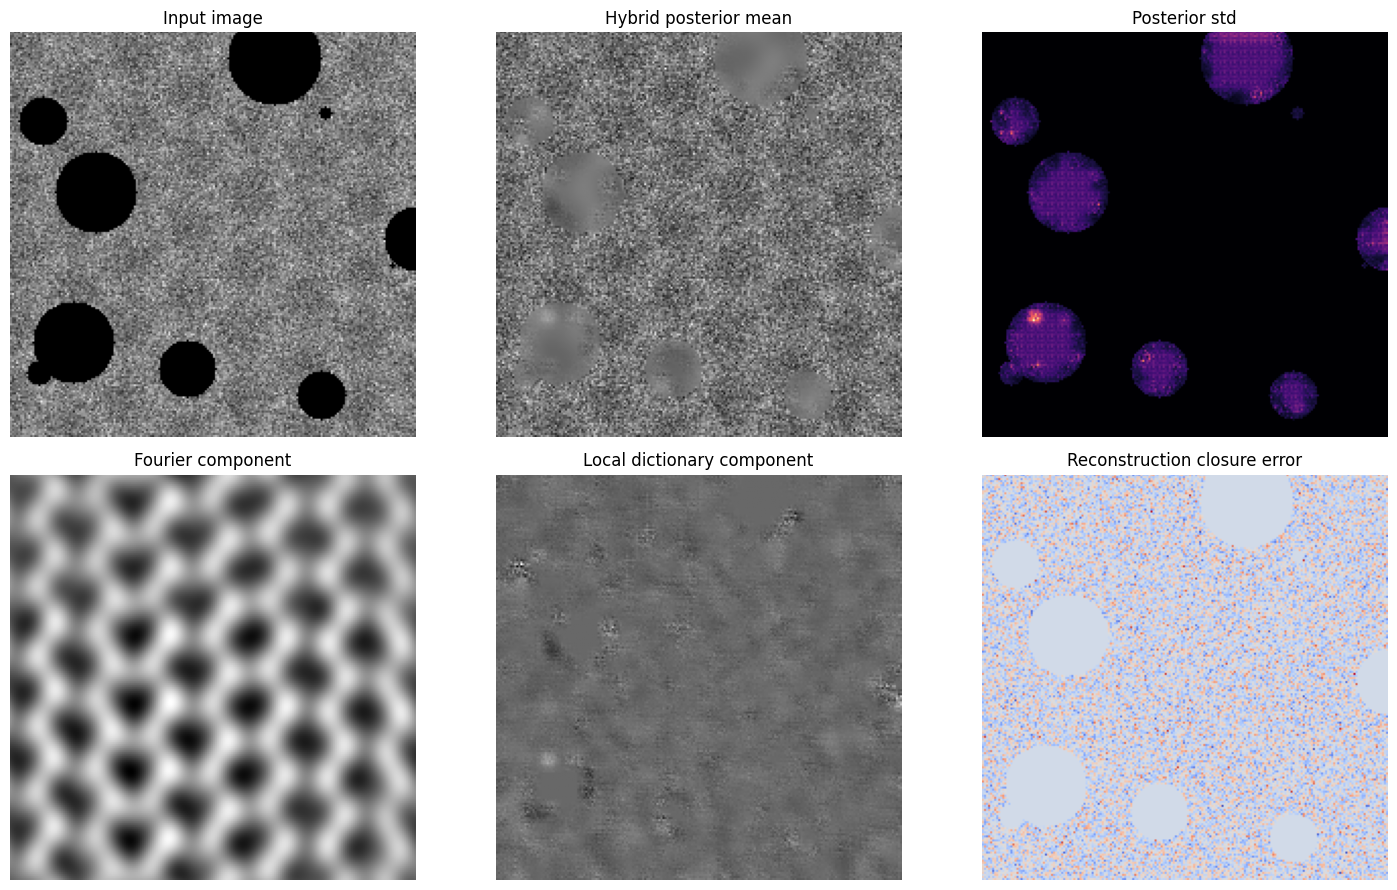

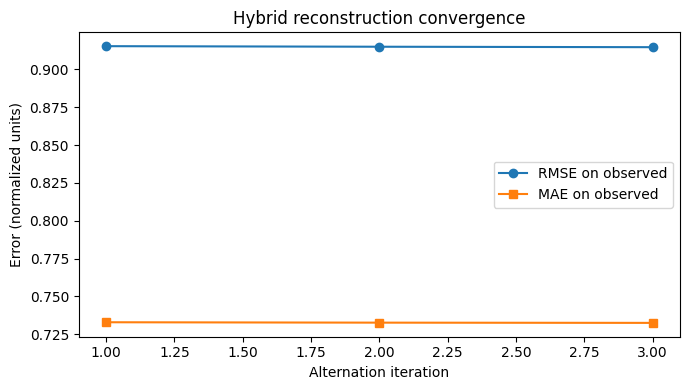

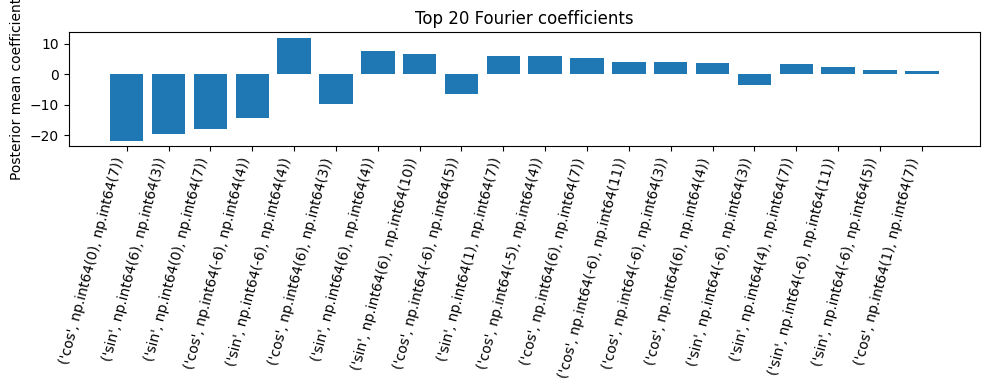

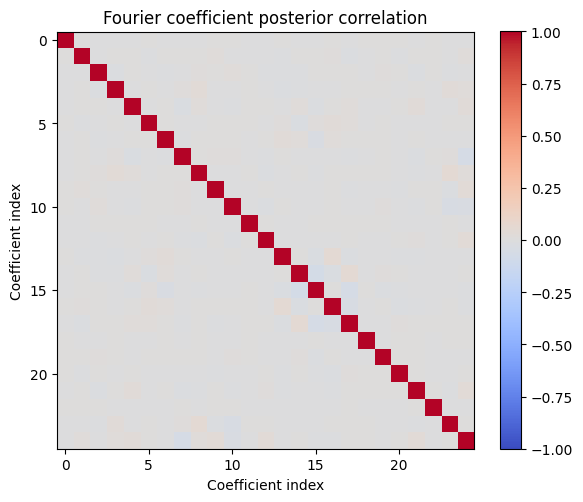

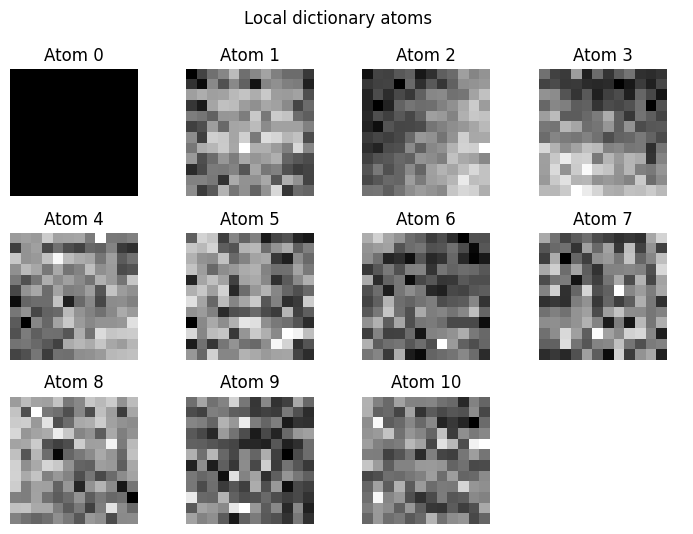

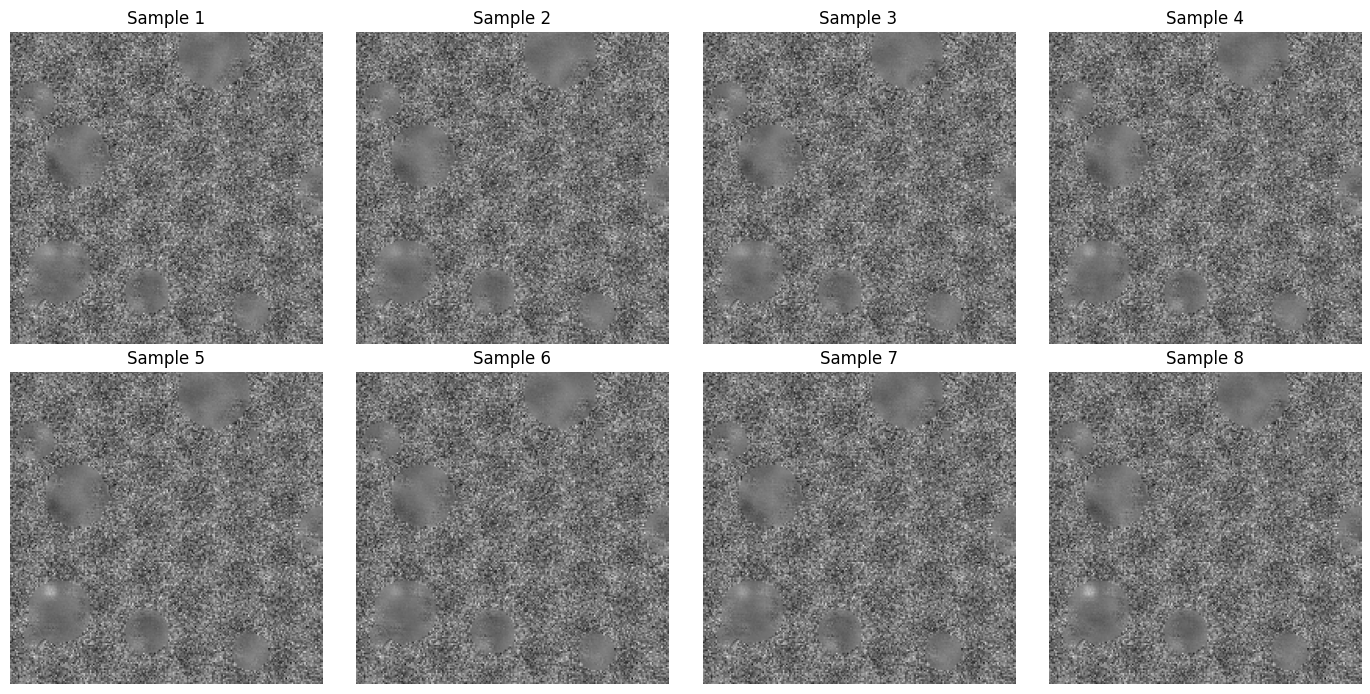

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import MiniBatchDictionaryLearning
from sklearn.linear_model import ARDRegression


# ============================================================
# Basic utilities
# ============================================================

def _patch_starts(length, patch_size, stride):
    starts = list(range(0, max(length - patch_size + 1, 1), stride))
    last = length - patch_size
    if last < 0:
        raise ValueError("patch_size must be <= image dimensions")
    if len(starts) == 0 or starts[-1] != last:
        starts.append(last)
    return starts


def _iter_patch_coords(H, W, patch_size, stride):
    rows = _patch_starts(H, patch_size, stride)
    cols = _patch_starts(W, patch_size, stride)
    for i in rows:
        for j in cols:
            yield i, j


def _soft_window(patch_size):
    if patch_size < 3:
        return np.ones((patch_size, patch_size), dtype=float)
    w1 = np.hanning(patch_size)
    if np.allclose(w1, 0):
        w1 = np.ones_like(w1)
    else:
        w1 = 0.25 + 0.75 * (w1 / w1.max())
    return np.outer(w1, w1)


def _normalize_observed(image_fill, valid_mask):
    obs = image_fill[valid_mask]
    mu = float(np.mean(obs))
    sigma = float(np.std(obs))
    if sigma < 1e-8:
        sigma = 1.0
    image_norm = (image_fill - mu) / sigma
    return image_norm, mu, sigma


def _gaussian_posterior_fallback(A, y, B_full, noise_std=0.05, prior_var=1.0):
    """
    Generic linear-Gaussian posterior fallback:
        coeff ~ N(0, prior_var I)
        y = A coeff + eps, eps ~ N(0, noise_std^2 I)
    """
    K = A.shape[1]
    noise_var = noise_std ** 2
    precision = (A.T @ A) / noise_var + np.eye(K) / prior_var
    Sigma = np.linalg.inv(precision)
    mu = Sigma @ (A.T @ y) / noise_var

    x_mu = B_full @ mu
    x_var = np.einsum("ij,jk,ik->i", B_full, Sigma, B_full)
    x_var = np.maximum(x_var, 0.0)

    return mu, Sigma, x_mu, x_var


def _fit_ard_posterior(A, y, B_full, noise_std=0.05, ard_max_iter=500, ard_tol=1e-4):
    """
    Fit ARD regression:
        y = A coeff + eps
    and propagate posterior to full basis B_full.
    """
    K = A.shape[1]

    if len(y) == 0:
        mu = np.zeros(K, dtype=float)
        Sigma = np.eye(K, dtype=float)
        x_mu = B_full @ mu
        x_var = np.einsum("ij,jk,ik->i", B_full, Sigma, B_full)
        return mu, Sigma, x_mu, np.maximum(x_var, 0.0)

    if len(y) < min(4, K):
        return _gaussian_posterior_fallback(A, y, B_full, noise_std=noise_std, prior_var=1.0)

    try:
        try:
            ard = ARDRegression(
                fit_intercept=False,
                max_iter=ard_max_iter,
                tol=ard_tol
            )
        except TypeError:
            ard = ARDRegression(
                fit_intercept=False,
                n_iter=ard_max_iter,
                tol=ard_tol
            )

        ard.fit(A, y)
        mu = np.asarray(ard.coef_, dtype=float)
        Sigma = np.asarray(ard.sigma_, dtype=float)

        # Defensive fallback if sigma_ is not well formed
        if Sigma.ndim != 2 or Sigma.shape != (K, K):
            raise RuntimeError("ARDRegression returned an unexpected covariance shape.")

        x_mu = B_full @ mu
        x_var = np.einsum("ij,jk,ik->i", B_full, Sigma, B_full)
        x_var = np.maximum(x_var, 0.0)

        return mu, Sigma, x_mu, x_var

    except Exception:
        return _gaussian_posterior_fallback(A, y, B_full, noise_std=noise_std, prior_var=1.0)


# ============================================================
# Fourier block
# ============================================================

def select_candidate_frequencies(
    image_norm,
    valid_mask,
    max_freqs=64,
    known_peak_coords=None
):
    """
    Select candidate frequencies from the zero-filled observed image.
    Frequencies are in rfft2 indexing: (ky_idx, kx_idx)
    """
    H, W = image_norm.shape
    x0 = np.zeros_like(image_norm)
    x0[valid_mask] = image_norm[valid_mask]

    spec = np.fft.rfft2(x0)
    mag = np.abs(spec)
    mag[0, 0] = 0.0

    freq_list = []

    if known_peak_coords is not None:
        for f in known_peak_coords:
            ky, kx = int(f[0]), int(f[1])
            if 0 <= ky < H and 0 <= kx <= W // 2 and (ky, kx) != (0, 0):
                if (ky, kx) not in freq_list:
                    freq_list.append((ky, kx))

    flat_idx = np.argsort(mag.ravel())[::-1]
    for idx in flat_idx:
        ky, kx = np.unravel_index(idx, mag.shape)
        if (ky, kx) == (0, 0):
            continue
        if (ky, kx) not in freq_list:
            freq_list.append((ky, kx))
        if len(freq_list) >= (len(known_peak_coords) if known_peak_coords else 0) + max_freqs:
            break

    return freq_list


def build_real_fourier_dictionary(H, W, freq_list, include_dc=True):
    """
    Real-valued Fourier basis matrix Phi with shape (H*W, K).
    """
    yy, xx = np.meshgrid(np.arange(H), np.arange(W), indexing="ij")
    yy = yy.ravel().astype(float)
    xx = xx.ravel().astype(float)

    atoms = []
    labels = []

    if include_dc:
        dc = np.ones(H * W, dtype=float)
        dc /= np.linalg.norm(dc) + 1e-12
        atoms.append(dc)
        labels.append(("dc", 0, 0))

    for ky_idx, kx_idx in freq_list:
        ky_signed = ky_idx if ky_idx <= H // 2 else ky_idx - H
        phase = 2.0 * np.pi * (ky_signed * yy / H + kx_idx * xx / W)

        c = np.cos(phase)
        c_norm = np.linalg.norm(c)
        if c_norm > 1e-10:
            atoms.append(c / c_norm)
            labels.append(("cos", ky_signed, kx_idx))

        s = np.sin(phase)
        s_norm = np.linalg.norm(s)
        if s_norm > 1e-10:
            atoms.append(s / s_norm)
            labels.append(("sin", ky_signed, kx_idx))

    Phi = np.column_stack(atoms)
    return Phi, labels


# ============================================================
# Local dictionary block
# ============================================================

def _collect_training_patches(
    image_norm,
    valid_mask,
    patch_size=8,
    train_stride=2,
    max_train_patches=20000,
    min_valid_frac=0.98,
    random_state=0
):
    H, W = image_norm.shape
    patches = []

    for i, j in _iter_patch_coords(H, W, patch_size, train_stride):
        patch = image_norm[i:i+patch_size, j:j+patch_size]
        maskp = valid_mask[i:i+patch_size, j:j+patch_size]
        frac = maskp.mean()

        if frac >= min_valid_frac:
            p = patch.copy()
            p[~maskp] = 0.0
            patches.append(p.ravel())

    if len(patches) == 0:
        raise RuntimeError("No training patches found. Lower min_valid_frac or provide more visible data.")

    patches = np.asarray(patches, dtype=float)
    rng = np.random.default_rng(random_state)
    if len(patches) > max_train_patches:
        idx = rng.choice(len(patches), size=max_train_patches, replace=False)
        patches = patches[idx]

    return patches


def learn_dictionary_from_visible_patches(
    image_norm,
    valid_mask,
    patch_size=8,
    n_components=128,
    train_stride=2,
    max_train_patches=20000,
    min_valid_frac=0.98,
    dict_alpha=1.0,
    batch_size=256,
    n_iter=500,
    random_state=0,
    add_dc_atom=True
):
    patches = _collect_training_patches(
        image_norm=image_norm,
        valid_mask=valid_mask,
        patch_size=patch_size,
        train_stride=train_stride,
        max_train_patches=max_train_patches,
        min_valid_frac=min_valid_frac,
        random_state=random_state
    )

    learner = MiniBatchDictionaryLearning(
        n_components=n_components,
        alpha=dict_alpha,
        batch_size=batch_size,
        max_iter=n_iter,
        random_state=random_state,
        verbose=False
    )
    learner.fit(patches)

    D = learner.components_.T  # (patch_dim, n_atoms)

    if add_dc_atom:
        dc = np.ones((D.shape[0], 1), dtype=float)
        dc /= np.linalg.norm(dc) + 1e-12
        D = np.concatenate([dc, D], axis=1)

    D /= (np.linalg.norm(D, axis=0, keepdims=True) + 1e-12)
    return D


def bayesian_patch_dictionary_posterior(
    patch_norm,
    valid_patch_mask,
    D,
    noise_std=0.05,
    ard_max_iter=300,
    ard_tol=1e-4,
    return_coeff_posterior=True
):
    """
    Patch model:
        patch ≈ D alpha
    observed only on valid pixels.
    """
    y_full = patch_norm.ravel()
    obs_idx = valid_patch_mask.ravel()
    y_obs = y_full[obs_idx]

    D_obs = D[obs_idx, :]
    D_full = D

    alpha_mean, alpha_cov, x_mu, x_var = _fit_ard_posterior(
        A=D_obs,
        y=y_obs,
        B_full=D_full,
        noise_std=noise_std,
        ard_max_iter=ard_max_iter,
        ard_tol=ard_tol
    )

    if return_coeff_posterior:
        return x_mu, x_var, alpha_mean, alpha_cov
    return x_mu, x_var, None, None


# ============================================================
# Hybrid alternating reconstruction
# ============================================================

def hybrid_fourier_dictionary_reconstruct(
    image_occlude,
    mask_missing=None,
    # Fourier
    max_freqs=64,
    known_peak_coords=None,
    # Dictionary
    patch_size=12,
    stride=1,
    train_stride=2,
    n_components=192,
    dict_alpha=1.0,
    max_train_patches=15000,
    min_train_valid_frac=0.98,
    # Alternation / noise
    n_alt_iters=3,
    noise_std=0.05,
    ard_max_iter=400,
    ard_tol=1e-4,
    # Behavior
    process_all_patches=True,
    enforce_observed_pixels=True,
    clip_to_observed_range=False,
    # Storage
    store_patch_posteriors=True,
    random_state=0
):
    """
    Hybrid reconstruction:
        x ≈ Fourier background + local patch dictionary residual

    Returns
    -------
    recon : 2D ndarray
        Posterior-mean reconstruction
    unc : 2D ndarray
        Approximate posterior std
    info : dict
        All relevant parameters and intermediate objects
    """
    image = np.asarray(image_occlude, dtype=float)
    if image.ndim != 2:
        raise ValueError("Expected a 2D grayscale image.")

    H, W = image.shape

    if mask_missing is None:
        mask_missing = ~np.isfinite(image)
    else:
        mask_missing = np.asarray(mask_missing, dtype=bool)
        if mask_missing.shape != image.shape:
            raise ValueError("mask_missing must match image shape.")

    valid_mask = ~mask_missing
    if valid_mask.sum() == 0:
        raise ValueError("No observed pixels available.")

    image_fill = image.copy()
    observed_mean = np.nanmean(image_fill[valid_mask])
    image_fill[mask_missing] = observed_mean

    image_norm, obs_mu, obs_sigma = _normalize_observed(image_fill, valid_mask)

    # Learn local dictionary
    D = learn_dictionary_from_visible_patches(
        image_norm=image_norm,
        valid_mask=valid_mask,
        patch_size=patch_size,
        n_components=n_components,
        train_stride=train_stride,
        max_train_patches=max_train_patches,
        min_valid_frac=min_train_valid_frac,
        dict_alpha=dict_alpha,
        random_state=random_state
    )

    # Fourier basis
    freq_list = select_candidate_frequencies(
        image_norm=image_norm,
        valid_mask=valid_mask,
        max_freqs=max_freqs,
        known_peak_coords=known_peak_coords
    )
    Phi_full, atom_labels = build_real_fourier_dictionary(H, W, freq_list, include_dc=True)
    Phi_obs = Phi_full[valid_mask.ravel(), :]

    win = _soft_window(patch_size)

    # Initialize local component to zero
    local_mean_norm = np.zeros_like(image_norm)
    local_var_norm = np.zeros_like(image_norm)

    history = []
    final_patch_posteriors = []
    final_weight_den = None

    for it in range(n_alt_iters):
        # ----------------------------------------------------
        # Fourier update on residual after removing local mean
        # ----------------------------------------------------
        target_fourier_norm = image_norm - local_mean_norm
        y_fourier_obs = target_fourier_norm.ravel()[valid_mask.ravel()]

        beta_mean, beta_cov, fourier_mean_flat, fourier_var_flat = _fit_ard_posterior(
            A=Phi_obs,
            y=y_fourier_obs,
            B_full=Phi_full,
            noise_std=noise_std,
            ard_max_iter=ard_max_iter,
            ard_tol=ard_tol
        )

        fourier_mean_norm = fourier_mean_flat.reshape(H, W)
        fourier_var_norm = fourier_var_flat.reshape(H, W)

        # ----------------------------------------------------
        # Local dictionary update on residual after removing Fourier mean
        # ----------------------------------------------------
        residual_for_local = image_norm - fourier_mean_norm

        local_num = np.zeros_like(image_norm, dtype=float)
        local_var_num = np.zeros_like(image_norm, dtype=float)
        weight_den = np.zeros_like(image_norm, dtype=float)

        patch_posteriors = []

        for i, j in _iter_patch_coords(H, W, patch_size, stride):
            miss_patch = mask_missing[i:i+patch_size, j:j+patch_size]

            if (not process_all_patches) and (not np.any(miss_patch)):
                continue

            patch = residual_for_local[i:i+patch_size, j:j+patch_size]
            valid_patch = valid_mask[i:i+patch_size, j:j+patch_size]

            x_mu_flat, x_var_flat, alpha_mean, alpha_cov = bayesian_patch_dictionary_posterior(
                patch_norm=patch,
                valid_patch_mask=valid_patch,
                D=D,
                noise_std=noise_std,
                ard_max_iter=ard_max_iter,
                ard_tol=ard_tol,
                return_coeff_posterior=store_patch_posteriors
            )

            patch_mu = x_mu_flat.reshape(patch_size, patch_size)
            patch_var = x_var_flat.reshape(patch_size, patch_size)

            local_num[i:i+patch_size, j:j+patch_size] += win * patch_mu
            local_var_num[i:i+patch_size, j:j+patch_size] += (win**2) * patch_var
            weight_den[i:i+patch_size, j:j+patch_size] += win

            if store_patch_posteriors:
                patch_posteriors.append({
                    "coord": (i, j),
                    "alpha_mean": alpha_mean,
                    "alpha_cov": alpha_cov,
                    "valid_patch_mask": valid_patch.copy(),
                    "x_patch_mean": patch_mu.copy(),
                    "x_patch_var": patch_var.copy(),
                })

        local_mean_norm_new = np.zeros_like(image_norm)
        local_var_norm_new = np.zeros_like(image_norm)

        covered = weight_den > 0
        local_mean_norm_new[covered] = local_num[covered] / weight_den[covered]
        local_var_norm_new[covered] = local_var_num[covered] / np.maximum(weight_den[covered]**2, 1e-12)

        # For uncovered pixels, leave local block at zero with broad-ish prior uncertainty 0
        local_mean_norm = local_mean_norm_new
        local_var_norm = np.maximum(local_var_norm_new, 0.0)

        # ----------------------------------------------------
        # Track diagnostics
        # ----------------------------------------------------
        recon_mean_norm = fourier_mean_norm + local_mean_norm
        obs_resid = recon_mean_norm[valid_mask] - image_norm[valid_mask]
        rmse_obs = float(np.sqrt(np.mean(obs_resid**2)))
        mae_obs = float(np.mean(np.abs(obs_resid)))

        history.append({
            "iteration": it + 1,
            "rmse_observed_norm": rmse_obs,
            "mae_observed_norm": mae_obs,
            "n_fourier_atoms": Phi_full.shape[1],
            "n_local_atoms": D.shape[1],
            "n_processed_patches": len(patch_posteriors) if store_patch_posteriors else int(np.sum(covered)),
        })

        final_patch_posteriors = patch_posteriors
        final_weight_den = weight_den.copy()

    # Final combine
    recon_mean_norm = fourier_mean_norm + local_mean_norm

    # Approximate variance: ignore cross-covariance between global and local blocks
    total_var_norm = np.maximum(fourier_var_norm + local_var_norm, 0.0)

    recon = recon_mean_norm * obs_sigma + obs_mu
    unc = np.sqrt(total_var_norm) * obs_sigma

    if enforce_observed_pixels and np.any(mask_missing):
        recon[valid_mask] = image_fill[valid_mask]
        unc[valid_mask] = 0.0

    if clip_to_observed_range:
        vmin = np.nanmin(image_fill[valid_mask])
        vmax = np.nanmax(image_fill[valid_mask])
        recon = np.clip(recon, vmin, vmax)

    info = {
        # Input / masks
        "image_shape": (H, W),
        "mask_missing": mask_missing,
        "valid_mask": valid_mask,
        "image_fill": image_fill,
        # Normalization
        "obs_mu": obs_mu,
        "obs_sigma": obs_sigma,
        # Fourier block
        "Phi_full": Phi_full,
        "freq_list_rfft": freq_list,
        "atom_labels": atom_labels,
        "mu_beta": beta_mean,
        "Sigma_beta": beta_cov,
        "fourier_mean_norm": fourier_mean_norm,
        "fourier_var_norm": fourier_var_norm,
        # Local block
        "D_local": D,
        "patch_size": patch_size,
        "stride": stride,
        "window": win,
        "local_mean_norm": local_mean_norm,
        "local_var_norm": local_var_norm,
        "patch_posteriors": final_patch_posteriors,
        "patch_weight_den": final_weight_den,
        # Combined
        "recon_mean_norm": recon_mean_norm,
        "recon_var_norm": total_var_norm,
        # Diagnostics / settings
        "history": history,
        "settings": {
            "max_freqs": max_freqs,
            "known_peak_coords": known_peak_coords,
            "n_components": n_components,
            "dict_alpha": dict_alpha,
            "noise_std": noise_std,
            "n_alt_iters": n_alt_iters,
            "process_all_patches": process_all_patches,
            "enforce_observed_pixels": enforce_observed_pixels,
            "store_patch_posteriors": store_patch_posteriors,
        }
    }

    return recon, unc, info


# ============================================================
# Posterior sampling
# ============================================================

def sample_hybrid_posterior(info, n_samples=8, random_state=0, enforce_observed=True):
    """
    Sample approximate posterior images from:
      - global Fourier posterior over beta
      - patchwise local posteriors over alpha_r

    Requires store_patch_posteriors=True during reconstruction.
    """
    if "patch_posteriors" not in info or len(info["patch_posteriors"]) == 0:
        raise ValueError("No stored patch posteriors. Run reconstruction with store_patch_posteriors=True.")

    rng = np.random.default_rng(random_state)

    H, W = info["image_shape"]
    patch_size = info["patch_size"]
    win = info["window"]
    D = info["D_local"]
    Phi_full = info["Phi_full"]

    mu_beta = info["mu_beta"]
    Sigma_beta = info["Sigma_beta"]

    obs_mu = info["obs_mu"]
    obs_sigma = info["obs_sigma"]

    valid_mask = info["valid_mask"]
    image_fill = info["image_fill"]

    beta_samples = rng.multivariate_normal(mu_beta, Sigma_beta, size=n_samples)
    fourier_samples_norm = beta_samples @ Phi_full.T
    fourier_samples_norm = fourier_samples_norm.reshape(n_samples, H, W)

    out = np.zeros((n_samples, H, W), dtype=float)

    for s in range(n_samples):
        local_num = np.zeros((H, W), dtype=float)
        weight_den = np.zeros((H, W), dtype=float)

        for pp in info["patch_posteriors"]:
            i, j = pp["coord"]
            alpha_mean = pp["alpha_mean"]
            alpha_cov = pp["alpha_cov"]

            alpha_s = rng.multivariate_normal(alpha_mean, alpha_cov)
            patch_s = (D @ alpha_s).reshape(patch_size, patch_size)

            local_num[i:i+patch_size, j:j+patch_size] += win * patch_s
            weight_den[i:i+patch_size, j:j+patch_size] += win

        local_s_norm = np.zeros((H, W), dtype=float)
        covered = weight_den > 0
        local_s_norm[covered] = local_num[covered] / weight_den[covered]

        x_s_norm = fourier_samples_norm[s] + local_s_norm
        x_s = x_s_norm * obs_sigma + obs_mu

        if enforce_observed and np.any(~valid_mask):
            x_s[valid_mask] = image_fill[valid_mask]

        out[s] = x_s

    return out


# ============================================================
# Access helpers
# ============================================================

def extract_hybrid_parameters(info):
    """
    Convenient numerical access to the most relevant posterior objects.
    """
    return {
        "mu_beta": np.asarray(info["mu_beta"], dtype=float),
        "Sigma_beta": np.asarray(info["Sigma_beta"], dtype=float),
        "D_local": np.asarray(info["D_local"], dtype=float),
        "fourier_mean_norm": np.asarray(info["fourier_mean_norm"], dtype=float),
        "fourier_var_norm": np.asarray(info["fourier_var_norm"], dtype=float),
        "local_mean_norm": np.asarray(info["local_mean_norm"], dtype=float),
        "local_var_norm": np.asarray(info["local_var_norm"], dtype=float),
        "recon_mean_norm": np.asarray(info["recon_mean_norm"], dtype=float),
        "recon_var_norm": np.asarray(info["recon_var_norm"], dtype=float),
        "atom_labels": info["atom_labels"],
        "history": info["history"],
        "patch_posteriors": info["patch_posteriors"],
    }


# ============================================================
# Visualization helpers
# ============================================================

def plot_hybrid_decomposition(image_occlude, recon, unc, info, cmap_img="gray", cmap_unc="magma"):
    H, W = info["image_shape"]
    obs_mu = info["obs_mu"]
    obs_sigma = info["obs_sigma"]

    fourier_mean = info["fourier_mean_norm"] * obs_sigma + obs_mu
    local_mean = info["local_mean_norm"] * obs_sigma
    total_std = unc

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))

    axes[0, 0].imshow(image_occlude, cmap=cmap_img)
    axes[0, 0].set_title("Input image")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(recon, cmap=cmap_img)
    axes[0, 1].set_title("Hybrid posterior mean")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(total_std, cmap=cmap_unc)
    axes[0, 2].set_title("Posterior std")
    axes[0, 2].axis("off")

    axes[1, 0].imshow(fourier_mean, cmap=cmap_img)
    axes[1, 0].set_title("Fourier component")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(local_mean, cmap=cmap_img)
    axes[1, 1].set_title("Local dictionary component")
    axes[1, 1].axis("off")

    residual = recon - (fourier_mean + local_mean)
    axes[1, 2].imshow(residual, cmap="coolwarm")
    axes[1, 2].set_title("Reconstruction closure error")
    axes[1, 2].axis("off")

    plt.tight_layout()
    plt.show()


def plot_hybrid_history(info):
    hist = info["history"]
    its = [h["iteration"] for h in hist]
    rmse = [h["rmse_observed_norm"] for h in hist]
    mae = [h["mae_observed_norm"] for h in hist]

    plt.figure(figsize=(7, 4))
    plt.plot(its, rmse, marker="o", label="RMSE on observed")
    plt.plot(its, mae, marker="s", label="MAE on observed")
    plt.xlabel("Alternation iteration")
    plt.ylabel("Error (normalized units)")
    plt.title("Hybrid reconstruction convergence")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_top_fourier_modes(info, top_k=20):
    mu_beta = np.asarray(info["mu_beta"], dtype=float)
    labels = info["atom_labels"]

    idx = np.argsort(np.abs(mu_beta))[::-1][:top_k]
    vals = mu_beta[idx]
    names = [str(labels[i]) for i in idx]

    plt.figure(figsize=(10, 4))
    plt.bar(np.arange(len(idx)), vals)
    plt.xticks(np.arange(len(idx)), names, rotation=75, ha="right")
    plt.ylabel("Posterior mean coefficient")
    plt.title(f"Top {top_k} Fourier coefficients")
    plt.tight_layout()
    plt.show()


def plot_beta_covariance(info, correlation=True, max_show=60):
    Sigma = np.asarray(info["Sigma_beta"], dtype=float)

    if correlation:
        d = np.sqrt(np.maximum(np.diag(Sigma), 1e-15))
        M = Sigma / np.outer(d, d)
        title = "Fourier coefficient posterior correlation"
        vmin, vmax = -1, 1
    else:
        M = Sigma
        title = "Fourier coefficient posterior covariance"
        vmin, vmax = None, None

    M = M[:max_show, :max_show]

    plt.figure(figsize=(6, 5))
    plt.imshow(M, cmap="coolwarm", vmin=vmin, vmax=vmax)
    plt.colorbar()
    plt.title(title)
    plt.xlabel("Coefficient index")
    plt.ylabel("Coefficient index")
    plt.tight_layout()
    plt.show()


def plot_dictionary_atoms(info, n_show=64):
    D = np.asarray(info["D_local"], dtype=float)
    ps = info["patch_size"]
    n_show = min(n_show, D.shape[1])

    ncols = int(np.ceil(np.sqrt(n_show)))
    nrows = int(np.ceil(n_show / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(1.8 * ncols, 1.8 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for k in range(n_show):
        atom = D[:, k].reshape(ps, ps)
        axes[k].imshow(atom, cmap="gray")
        axes[k].set_title(f"Atom {k}")
        axes[k].axis("off")

    for k in range(n_show, len(axes)):
        axes[k].axis("off")

    plt.suptitle("Local dictionary atoms")
    plt.tight_layout()
    plt.show()


def plot_posterior_samples(samples, ncols=4, cmap="gray"):
    n_samples = samples.shape[0]
    ncols = min(ncols, n_samples)
    nrows = int(np.ceil(n_samples / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.5 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i in range(n_samples):
        axes[i].imshow(samples[i], cmap=cmap)
        axes[i].set_title(f"Sample {i+1}")
        axes[i].axis("off")

    for i in range(n_samples, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# Example usage
# ============================================================

# Assumptions:
# 1) image_occlude is a 2D ndarray
# 2) missing pixels are either np.nan or provided via mask_missing


recon, unc, info = hybrid_fourier_dictionary_reconstruct(
    image_occlude,
    mask_missing=mask_missing,              # infer from NaNs
    max_freqs=12,
    known_peak_coords=None,         # e.g. [(0, 6), (5, 3)]
    patch_size=12,
    stride=5,
    train_stride=5,
    n_components=10,
    dict_alpha=1.0,
    n_alt_iters=3,
    noise_std=0.05,
    process_all_patches=True,
    enforce_observed_pixels=True,
    store_patch_posteriors=True,
    random_state=0
)

params = extract_hybrid_parameters(info)
mu_beta = params["mu_beta"]
Sigma_beta = params["Sigma_beta"]
D_local = params["D_local"]

plot_hybrid_decomposition(image_occlude, recon, unc, info)
plot_hybrid_history(info)
plot_top_fourier_modes(info, top_k=20)
plot_beta_covariance(info, correlation=True, max_show=50)
plot_dictionary_atoms(info, n_show=49)

samples = sample_hybrid_posterior(info, n_samples=8, random_state=0, enforce_observed=True)
plot_posterior_samples(samples)

# Phase field

# 4. Local Complex-Amplitude Fourier Reconstruction

In this example, the image is modeled using spatially varying complex Fourier coefficients rather than a single global coefficient per mode.

The reconstruction is written as

$$
x(r) = b(r) + \sum_{m=1}^{M} \mathrm{Re} \left[ c_m(r) \exp(i k_m \cdot r) \right]
$$

where $b(r)$ is a smooth background field, $k_m$ are selected reciprocal-space vectors, and $c_m(r)$ are local complex amplitudes.

Writing the local complex coefficient as

$$
c_m(r) = u_m(r) + i v_m(r)
$$

allows the model to be expressed in a form that is linear in the unknown coefficient fields. These fields are expanded on smooth spatial basis functions, so that the local amplitude and local phase of each Fourier mode can vary across the image.

This is a key step beyond global Fourier reconstruction, because it allows the algorithm to represent piecewise-shifted lattices, local strain, and phase discontinuities. After fitting the Bayesian linear model, we can recover not only the image prediction and its uncertainty, but also derived physical fields such as local amplitude, local phase, and approximate amplitude/phase uncertainty for each dominant mode.

This makes the method particularly attractive for images containing multiple translational defects or spatially varying lattice registry. Compared with the hybrid dictionary model, this representation is much more physically aligned with extended phase-type defects such as antiphase boundaries. However, in its basic form it still uses a relatively simple Gaussian prior on the latent coefficient fields. That means it favors smooth variation, but does not yet explicitly encode the idea that phase should be smooth inside domains and discontinuous only across a sparse set of defect lines.

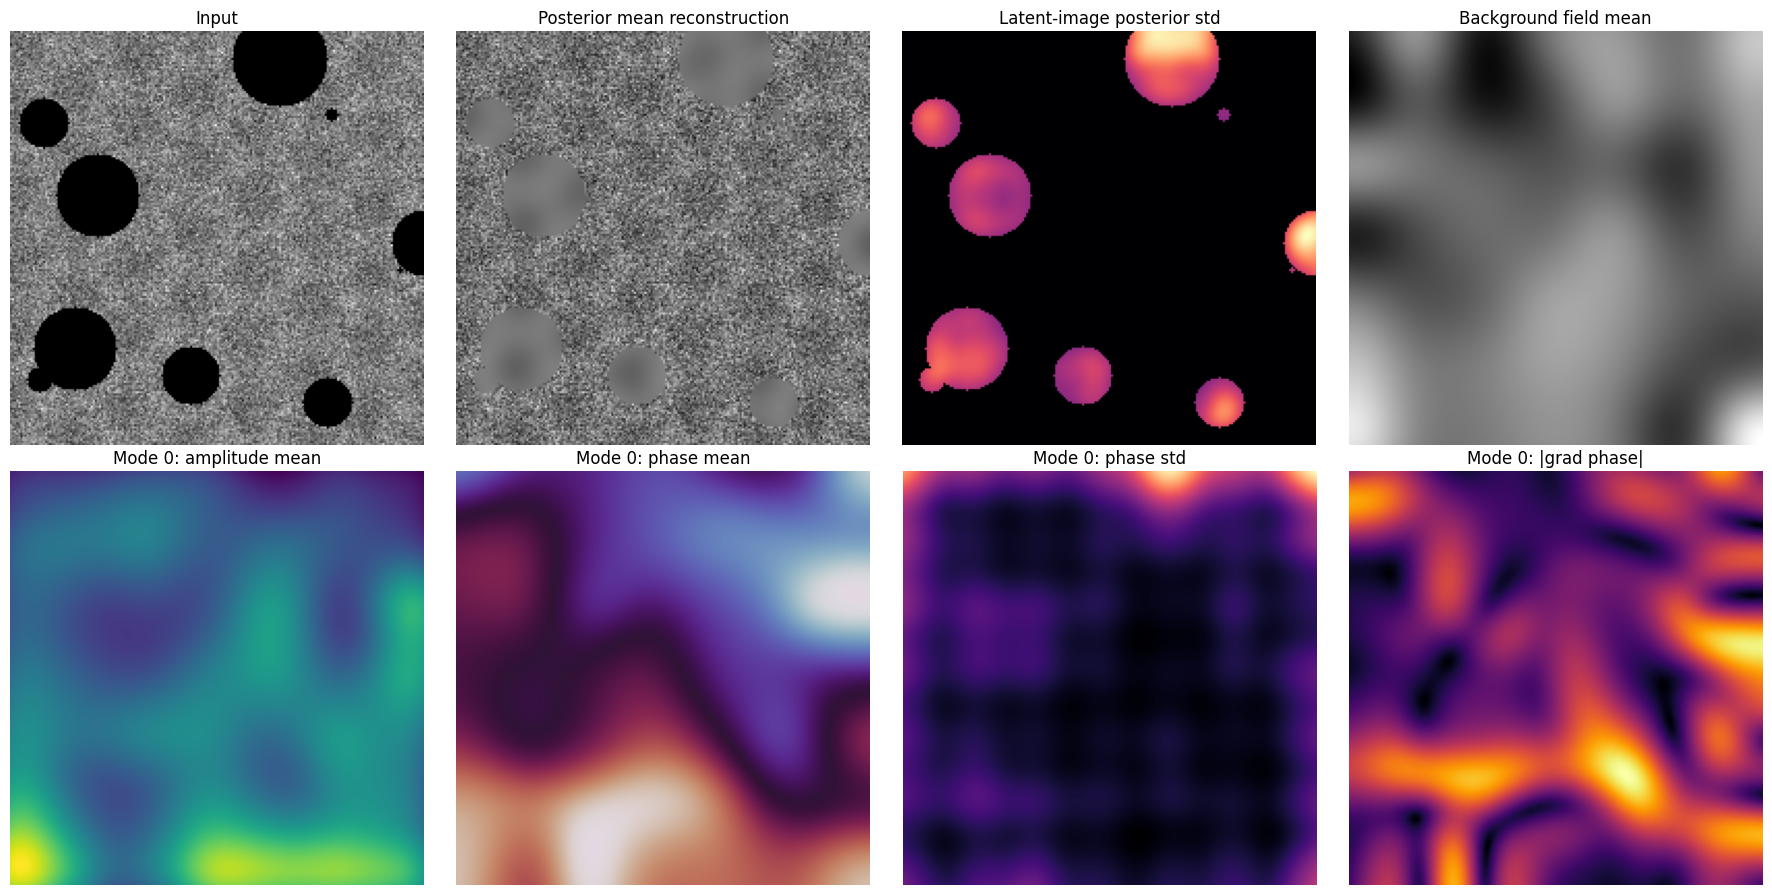

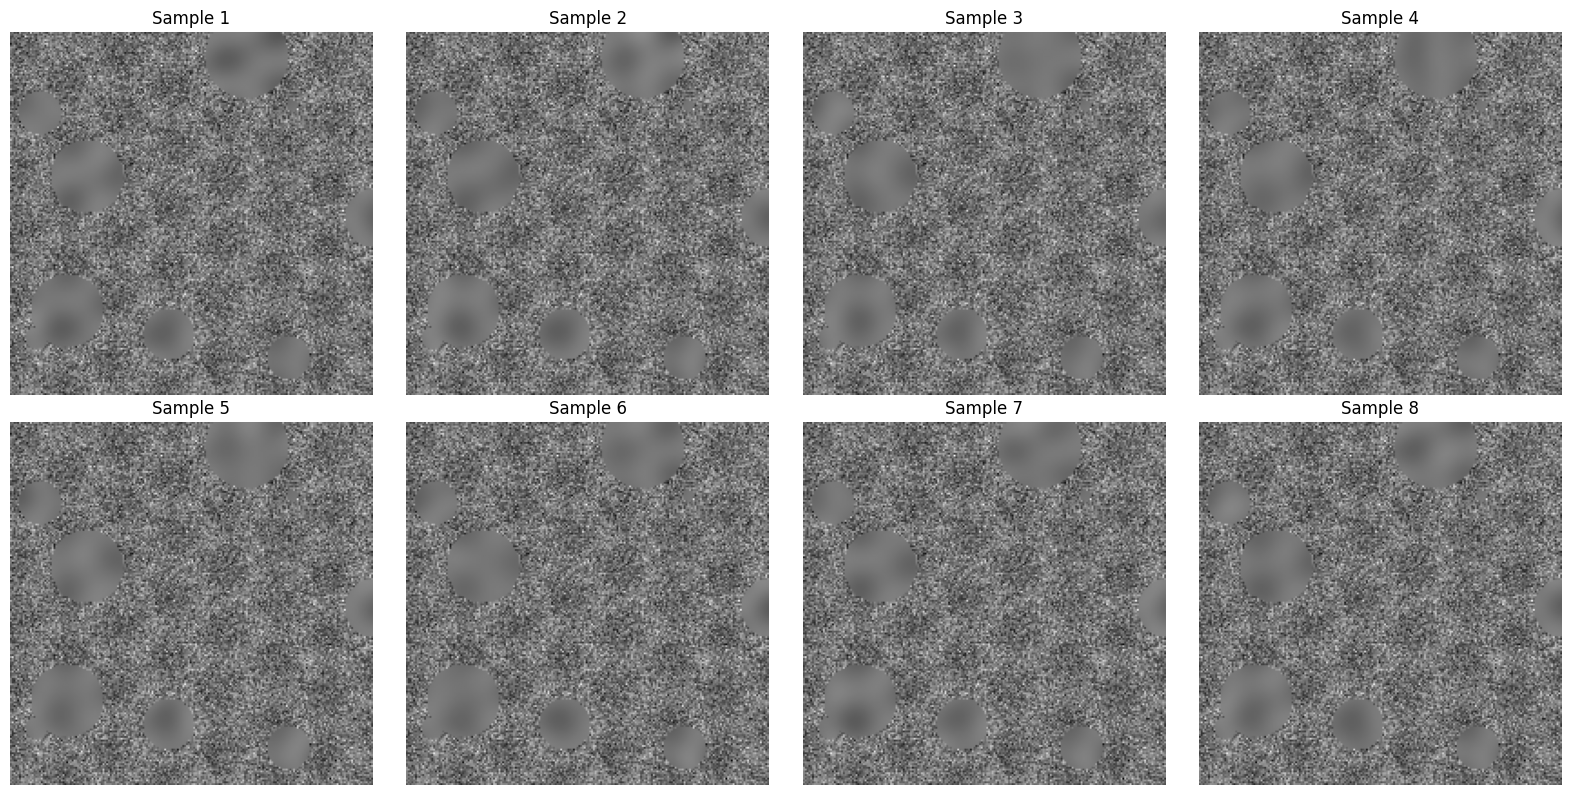

In [19]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import BayesianRidge


# ============================================================
# Basic utilities
# ============================================================

def _infer_mask(image, mask_missing=None):
    image = np.asarray(image, dtype=float)
    if image.ndim != 2:
        raise ValueError("Expected a 2D grayscale image.")
    if mask_missing is None:
        mask_missing = ~np.isfinite(image)
    else:
        mask_missing = np.asarray(mask_missing, dtype=bool)
        if mask_missing.shape != image.shape:
            raise ValueError("mask_missing must have the same shape as image.")
    valid_mask = ~mask_missing
    if valid_mask.sum() == 0:
        raise ValueError("No observed pixels available.")
    return image, mask_missing, valid_mask


def _normalize_observed(image, valid_mask):
    image_fill = image.copy()
    obs_mean = np.nanmean(image_fill[valid_mask])
    image_fill[~valid_mask] = obs_mean

    mu = float(np.mean(image_fill[valid_mask]))
    sigma = float(np.std(image_fill[valid_mask]))
    if sigma < 1e-8:
        sigma = 1.0

    image_norm = (image_fill - mu) / sigma
    return image_fill, image_norm, mu, sigma


def _fft_peak_candidates(image_norm, valid_mask, max_modes=4, known_peak_coords=None):
    """
    Return candidate frequencies in rfft2 indexing: (ky_idx, kx_idx)
    """
    H, W = image_norm.shape

    x0 = np.zeros_like(image_norm)
    x0[valid_mask] = image_norm[valid_mask]
    spec = np.fft.rfft2(x0)
    mag = np.abs(spec)
    mag[0, 0] = 0.0

    freq_list = []

    if known_peak_coords is not None:
        for ky, kx in known_peak_coords:
            ky = int(ky)
            kx = int(kx)
            if 0 <= ky < H and 0 <= kx <= W // 2:
                if (ky, kx) != (0, 0) and (ky, kx) not in freq_list:
                    freq_list.append((ky, kx))

    flat_idx = np.argsort(mag.ravel())[::-1]
    for idx in flat_idx:
        ky, kx = np.unravel_index(idx, mag.shape)
        if (ky, kx) == (0, 0):
            continue
        if (ky, kx) not in freq_list:
            freq_list.append((ky, kx))
        if len(freq_list) >= (len(known_peak_coords) if known_peak_coords else 0) + max_modes:
            break

    return freq_list


def _build_rbf_basis(H, W, spacing=24, sigma=None, include_constant=True, normalize=True):
    """
    Build smooth Gaussian RBF basis on a coarse grid.
    Returns G with shape (H*W, L), plus center coordinates.
    """
    yy, xx = np.meshgrid(np.arange(H), np.arange(W), indexing="ij")
    yyf = yy.ravel().astype(float)
    xxf = xx.ravel().astype(float)

    if sigma is None:
        sigma = 0.6 * spacing

    cy = np.arange(0, H, spacing, dtype=float)
    cx = np.arange(0, W, spacing, dtype=float)
    if cy[-1] != H - 1:
        cy = np.append(cy, H - 1)
    if cx[-1] != W - 1:
        cx = np.append(cx, W - 1)

    centers = [(y0, x0) for y0 in cy for x0 in cx]

    cols = []
    labels = []

    if include_constant:
        c = np.ones(H * W, dtype=float)
        if normalize:
            c /= (np.linalg.norm(c) + 1e-12)
        cols.append(c)
        labels.append(("const", None, None))

    for y0, x0 in centers:
        g = np.exp(-((yyf - y0) ** 2 + (xxf - x0) ** 2) / (2.0 * sigma ** 2))
        if normalize:
            g /= (np.linalg.norm(g) + 1e-12)
        cols.append(g)
        labels.append(("rbf", y0, x0))

    G = np.column_stack(cols)
    return G, centers, labels


def _signed_ky(ky_idx, H):
    return ky_idx if ky_idx <= H // 2 else ky_idx - H


# ============================================================
# Design matrix for local complex-amplitude model
# ============================================================

def _build_local_phase_design(H, W, G, freq_list):
    """
    Model:
        x(r) = G_bg(r) * gamma
             + sum_m [ G(r) * u_m * cos(k_m.r) - G(r) * v_m * sin(k_m.r) ]

    Returns
    -------
    X_full : (Npix, P)
    meta   : dict with slices and labels
    """
    Npix, L = G.shape
    yy, xx = np.meshgrid(np.arange(H), np.arange(W), indexing="ij")
    yyf = yy.ravel().astype(float)
    xxf = xx.ravel().astype(float)

    blocks = []
    labels = []
    mode_slices = []

    # Background block
    bg_slice = slice(0, L)
    blocks.append(G)
    labels.extend([("bg", j) for j in range(L)])

    col_start = L

    for m, (ky_idx, kx_idx) in enumerate(freq_list):
        ky = _signed_ky(ky_idx, H)
        phase = 2.0 * np.pi * (ky * yyf / H + kx_idx * xxf / W)
        c = np.cos(phase)
        s = np.sin(phase)

        Xu = G * c[:, None]
        Xv = G * (-s[:, None])

        u_slice = slice(col_start, col_start + L)
        v_slice = slice(col_start + L, col_start + 2 * L)

        blocks.append(Xu)
        blocks.append(Xv)

        labels.extend([("u", m, j) for j in range(L)])
        labels.extend([("v", m, j) for j in range(L)])

        mode_slices.append({
            "mode_index": m,
            "freq_rfft": (ky_idx, kx_idx),
            "freq_signed": (ky, kx_idx),
            "u_slice": u_slice,
            "v_slice": v_slice,
        })

        col_start += 2 * L

    X_full = np.column_stack(blocks)

    meta = {
        "bg_slice": bg_slice,
        "mode_slices": mode_slices,
        "labels": labels,
        "n_basis": L,
    }
    return X_full, meta


# ============================================================
# Main reconstruction
# ============================================================

def local_phase_fourier_reconstruct(
    image_occlude,
    mask_missing=None,
    max_modes=4,
    known_peak_coords=None,
    rbf_spacing=24,
    rbf_sigma=None,
    include_constant=True,
    fit_intercept=False,
    compute_score=False,
    clip_to_observed_range=False
):
    """
    Reconstruct image using local complex Fourier coefficients with Bayesian Ridge.

    Parameters
    ----------
    image_occlude : 2D ndarray
        Image, optionally with NaNs in missing regions.
    mask_missing : 2D bool ndarray or None
        True where missing.
    max_modes : int
        Number of FFT peaks to use automatically.
    known_peak_coords : list[(ky_idx, kx_idx)] or None
        Peaks in rfft2 indexing to force into the model.
    rbf_spacing : int
        Coarse-grid spacing for local coefficient fields.
    rbf_sigma : float or None
        Width of Gaussian RBFs. If None, defaults to 0.6 * spacing.

    Returns
    -------
    recon : 2D ndarray
        Posterior mean reconstruction.
    unc : 2D ndarray
        Posterior std map of latent clean image.
    info : dict
        All posterior objects and helper metadata.
    """
    image, mask_missing, valid_mask = _infer_mask(image_occlude, mask_missing)
    H, W = image.shape
    Npix = H * W

    image_fill, image_norm, obs_mu, obs_sigma = _normalize_observed(image, valid_mask)

    freq_list = _fft_peak_candidates(
        image_norm=image_norm,
        valid_mask=valid_mask,
        max_modes=max_modes,
        known_peak_coords=known_peak_coords
    )

    G, centers, basis_labels = _build_rbf_basis(
        H=H,
        W=W,
        spacing=rbf_spacing,
        sigma=rbf_sigma,
        include_constant=include_constant,
        normalize=True
    )

    X_full, meta = _build_local_phase_design(H, W, G, freq_list)

    y_full = image_norm.ravel()
    obs_idx = valid_mask.ravel()

    X_obs = X_full[obs_idx, :]
    y_obs = y_full[obs_idx]

    # Bayesian linear regression
    model = BayesianRidge(
        fit_intercept=fit_intercept,
        compute_score=compute_score
    )
    model.fit(X_obs, y_obs)

    mu_theta = np.asarray(model.coef_, dtype=float)
    Sigma_theta = np.asarray(model.sigma_, dtype=float)

    # Posterior mean in image space
    mean_flat_norm = X_full @ mu_theta

    # Latent-image posterior variance, not observation-noise predictive variance
    var_flat_norm = np.einsum("ij,jk,ik->i", X_full, Sigma_theta, X_full)
    var_flat_norm = np.maximum(var_flat_norm, 0.0)

    recon = mean_flat_norm.reshape(H, W) * obs_sigma + obs_mu
    unc = np.sqrt(var_flat_norm.reshape(H, W)) * obs_sigma

    # For inpainting, it is usually helpful to keep observed pixels exact
    if np.any(mask_missing):
        recon[valid_mask] = image_fill[valid_mask]
        unc[valid_mask] = 0.0

    if clip_to_observed_range:
        vmin = np.nanmin(image_fill[valid_mask])
        vmax = np.nanmax(image_fill[valid_mask])
        recon = np.clip(recon, vmin, vmax)

    info = {
        "image_shape": (H, W),
        "image_fill": image_fill,
        "mask_missing": mask_missing,
        "valid_mask": valid_mask,
        "obs_mu": obs_mu,
        "obs_sigma": obs_sigma,
        "freq_list_rfft": freq_list,
        "G": G,
        "rbf_centers": centers,
        "basis_labels": basis_labels,
        "X_full": X_full,
        "meta": meta,
        "mu_theta": mu_theta,
        "Sigma_theta": Sigma_theta,
        "alpha_noise_precision": getattr(model, "alpha_", None),
        "lambda_weight_precision": getattr(model, "lambda_", None),
        "scores_": getattr(model, "scores_", None),
        "recon_mean_norm": mean_flat_norm.reshape(H, W),
        "recon_var_norm": var_flat_norm.reshape(H, W),
    }

    return recon, unc, info


# ============================================================
# Extract local amplitude / phase fields
# ============================================================

def extract_mode_fields(info, mode_index=0, compute_uncertainty=True, unwrap_phase=True):
    """
    Extract posterior-mean local fields for one Fourier mode:
      U(r), V(r), amplitude A(r), phase phi(r)

    Model convention:
      contribution_m(r) = U(r) * cos(k.r) - V(r) * sin(k.r)
      with U = A cos(phi), V = A sin(phi)

    If compute_uncertainty=True, returns delta-method std for A and phi.
    """
    G = info["G"]
    mu_theta = info["mu_theta"]
    Sigma_theta = info["Sigma_theta"]
    H, W = info["image_shape"]

    ms = info["meta"]["mode_slices"][mode_index]
    u_slice = ms["u_slice"]
    v_slice = ms["v_slice"]

    mu_u = mu_theta[u_slice]
    mu_v = mu_theta[v_slice]

    U = (G @ mu_u).reshape(H, W)
    V = (G @ mu_v).reshape(H, W)

    A = np.sqrt(U ** 2 + V ** 2)
    phi = np.arctan2(V, U)

    if unwrap_phase:
        phi = np.unwrap(np.unwrap(phi, axis=0), axis=1)

    out = {
        "U_mean": U,
        "V_mean": V,
        "A_mean": A,
        "phi_mean": phi,
        "freq_rfft": ms["freq_rfft"],
        "freq_signed": ms["freq_signed"],
    }

    if compute_uncertainty:
        Suu = Sigma_theta[u_slice, u_slice]
        Svv = Sigma_theta[v_slice, v_slice]
        Suv = Sigma_theta[u_slice, v_slice]

        VarU = np.einsum("ij,jk,ik->i", G, Suu, G).reshape(H, W)
        VarV = np.einsum("ij,jk,ik->i", G, Svv, G).reshape(H, W)
        CovUV = np.einsum("ij,jk,ik->i", G, Suv, G).reshape(H, W)

        VarU = np.maximum(VarU, 0.0)
        VarV = np.maximum(VarV, 0.0)

        eps = 1e-12
        A_safe = np.maximum(A, eps)

        # Delta method
        dA_dU = U / A_safe
        dA_dV = V / A_safe

        dphi_dU = -V / (A_safe ** 2)
        dphi_dV = U / (A_safe ** 2)

        VarA = (dA_dU ** 2) * VarU + (dA_dV ** 2) * VarV + 2 * dA_dU * dA_dV * CovUV
        VarPhi = (dphi_dU ** 2) * VarU + (dphi_dV ** 2) * VarV + 2 * dphi_dU * dphi_dV * CovUV

        out["U_std"] = np.sqrt(np.maximum(VarU, 0.0))
        out["V_std"] = np.sqrt(np.maximum(VarV, 0.0))
        out["A_std"] = np.sqrt(np.maximum(VarA, 0.0))
        out["phi_std"] = np.sqrt(np.maximum(VarPhi, 0.0))

    return out


def extract_background_field(info, compute_uncertainty=True):
    G = info["G"]
    mu_theta = info["mu_theta"]
    Sigma_theta = info["Sigma_theta"]
    H, W = info["image_shape"]

    bg_slice = info["meta"]["bg_slice"]
    mu_bg = mu_theta[bg_slice]
    bg = (G @ mu_bg).reshape(H, W)

    out = {"bg_mean": bg}

    if compute_uncertainty:
        Sbg = Sigma_theta[bg_slice, bg_slice]
        VarBg = np.einsum("ij,jk,ik->i", G, Sbg, G).reshape(H, W)
        out["bg_std"] = np.sqrt(np.maximum(VarBg, 0.0))

    return out


# ============================================================
# Posterior sampling
# ============================================================

def sample_local_phase_posterior(info, n_samples=8, random_state=0, enforce_observed=True):
    """
    Draw posterior samples of the reconstructed image from:
        theta ~ N(mu_theta, Sigma_theta)
        x = X_full theta
    """
    rng = np.random.default_rng(random_state)

    mu_theta = info["mu_theta"]
    Sigma_theta = info["Sigma_theta"]
    X_full = info["X_full"]
    H, W = info["image_shape"]
    obs_mu = info["obs_mu"]
    obs_sigma = info["obs_sigma"]
    valid_mask = info["valid_mask"]
    image_fill = info["image_fill"]
    mask_missing = info["mask_missing"]

    theta_samples = rng.multivariate_normal(mu_theta, Sigma_theta, size=n_samples)
    x_samples_norm = theta_samples @ X_full.T
    x_samples = x_samples_norm.reshape(n_samples, H, W) * obs_sigma + obs_mu

    if enforce_observed and np.any(mask_missing):
        for s in range(n_samples):
            x_samples[s][valid_mask] = image_fill[valid_mask]

    return x_samples


# ============================================================
# Visualization
# ============================================================

def plot_local_phase_summary(image_occlude, recon, unc, info, mode_index=0):
    bg = extract_background_field(info, compute_uncertainty=False)["bg_mean"]
    mf = extract_mode_fields(info, mode_index=mode_index, compute_uncertainty=True, unwrap_phase=True)

    # APB-like map: large phase gradient magnitude
    gy, gx = np.gradient(mf["phi_mean"])
    phase_grad_mag = np.sqrt(gx ** 2 + gy ** 2)

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))

    axes[0, 0].imshow(image_occlude, cmap="gray")
    axes[0, 0].set_title("Input")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(recon, cmap="gray")
    axes[0, 1].set_title("Posterior mean reconstruction")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(unc, cmap="magma")
    axes[0, 2].set_title("Latent-image posterior std")
    axes[0, 2].axis("off")

    axes[0, 3].imshow(bg, cmap="gray")
    axes[0, 3].set_title("Background field mean")
    axes[0, 3].axis("off")

    axes[1, 0].imshow(mf["A_mean"], cmap="viridis")
    axes[1, 0].set_title(f"Mode {mode_index}: amplitude mean")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(mf["phi_mean"], cmap="twilight")
    axes[1, 1].set_title(f"Mode {mode_index}: phase mean")
    axes[1, 1].axis("off")

    if "phi_std" in mf:
        axes[1, 2].imshow(mf["phi_std"], cmap="magma")
        axes[1, 2].set_title(f"Mode {mode_index}: phase std")
        axes[1, 2].axis("off")
    else:
        axes[1, 2].axis("off")

    axes[1, 3].imshow(phase_grad_mag, cmap="inferno")
    axes[1, 3].set_title(f"Mode {mode_index}: |grad phase|")
    axes[1, 3].axis("off")

    plt.tight_layout()
    plt.show()


def plot_posterior_samples(samples, ncols=4):
    n = samples.shape[0]
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i in range(n):
        axes[i].imshow(samples[i], cmap="gray")
        axes[i].set_title(f"Sample {i+1}")
        axes[i].axis("off")

    for i in range(n, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# Example usage
# ============================================================

recon, unc, info = local_phase_fourier_reconstruct(
    image_occlude,
    mask_missing=mask_missing,          # infer from NaNs
    max_modes=4,
    known_peak_coords=None,     # or [(ky1, kx1), (ky2, kx2)]
    rbf_spacing=32,
    rbf_sigma=None,
    include_constant=True,
    clip_to_observed_range=False
)

mu_theta = info["mu_theta"]
Sigma_theta = info["Sigma_theta"]

mode0 = extract_mode_fields(info, mode_index=0, compute_uncertainty=True, unwrap_phase=True)
background = extract_background_field(info, compute_uncertainty=True)

plot_local_phase_summary(image_occlude, recon, unc, info, mode_index=0)

samples = sample_local_phase_posterior(info, n_samples=8, random_state=0, enforce_observed=True)
plot_posterior_samples(samples)

# Phase Field_Priors

5. APB-Aware Phase-Field Reconstruction with Smoothness and TV Priors

In this example, the image is modeled directly in terms of smooth amplitude fields and piecewise-smooth phase fields.

The reconstruction model is

$$
x(r) = b(r) + \sum_{m=1}^{M} A_m(r) \cos \left( k_m \cdot r + \phi_m(r) \right)
$$

Here, $b(r)$ is a smooth background, $A_m(r)$ are slowly varying local amplitudes, and $\phi_m(r)$ are local phase fields associated with dominant lattice modes. This formulation is particularly natural for antiphase boundaries and related translational defects, because an APB is represented directly as a jump or sharp gradient in the local phase field rather than as a large number of patch coefficients or global Fourier harmonics.

The prior in this model is explicitly defect-aware. Smoothness penalties are placed on the background and amplitude fields, while the phase fields are regularized by a combination of quadratic smoothness and weighted total variation. The corresponding structure is

$$
\lambda_b \, \| \nabla b \|_2^2
\;+\;
\lambda_A \sum_m \| \nabla A_m \|_2^2
\;+\;
\lambda_{\phi,\mathrm{smooth}} \sum_m \| \nabla \phi_m \|_2^2
\;+\;
\lambda_{\phi,\mathrm{tv}} \sum_m \mathrm{TV}(\phi_m)
$$

The smoothness term favors coherent phase within domains, whereas the TV term allows sparse sharp jumps, which is exactly the structure expected for APBs. In practice, this means the reconstruction prefers broad regions of nearly constant lattice phase separated by a relatively small set of boundary lines.

Because the model is nonlinear in the phase fields, the solution is obtained as a MAP estimate rather than a closed-form Gaussian posterior. Uncertainty is then approximated using a diagonal Laplace or Gauss-Newton approximation around the MAP solution.

The outputs therefore include the reconstructed image, an approximate posterior standard deviation, local amplitude and phase maps, phase-jump indicators such as $|\nabla \phi|$, and approximate posterior samples. This is the most physically faithful formulation among the methods implemented here when the image contains multiple APBs or a network of translational domain boundaries.

/tmp/ipykernel_5350/518189908.py:426: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


Iter 001 | objective = 23125522.447770
Iter 002 | objective = 23125522.447770


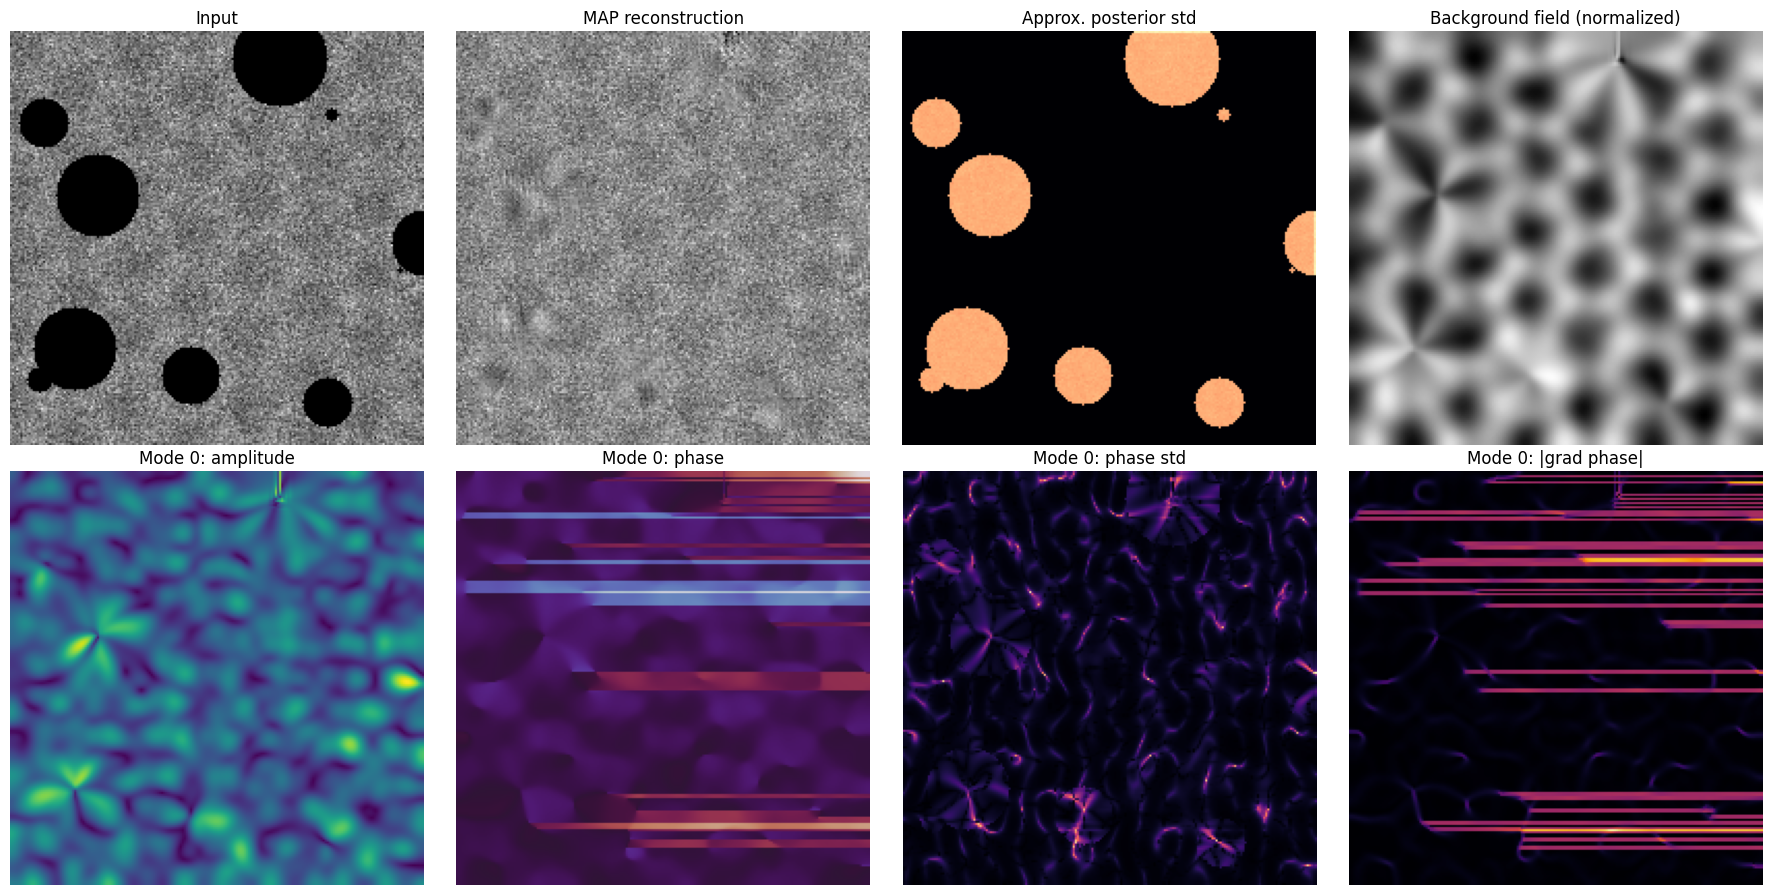

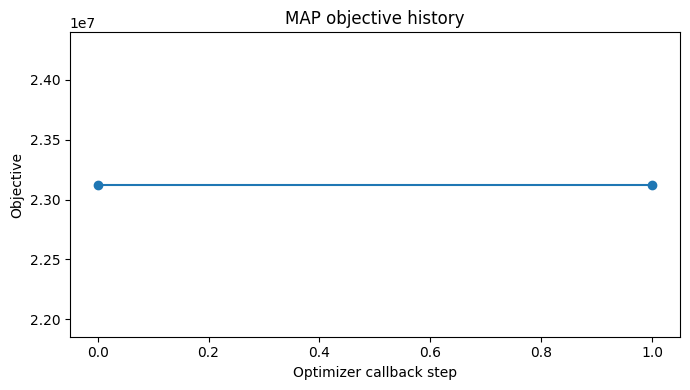

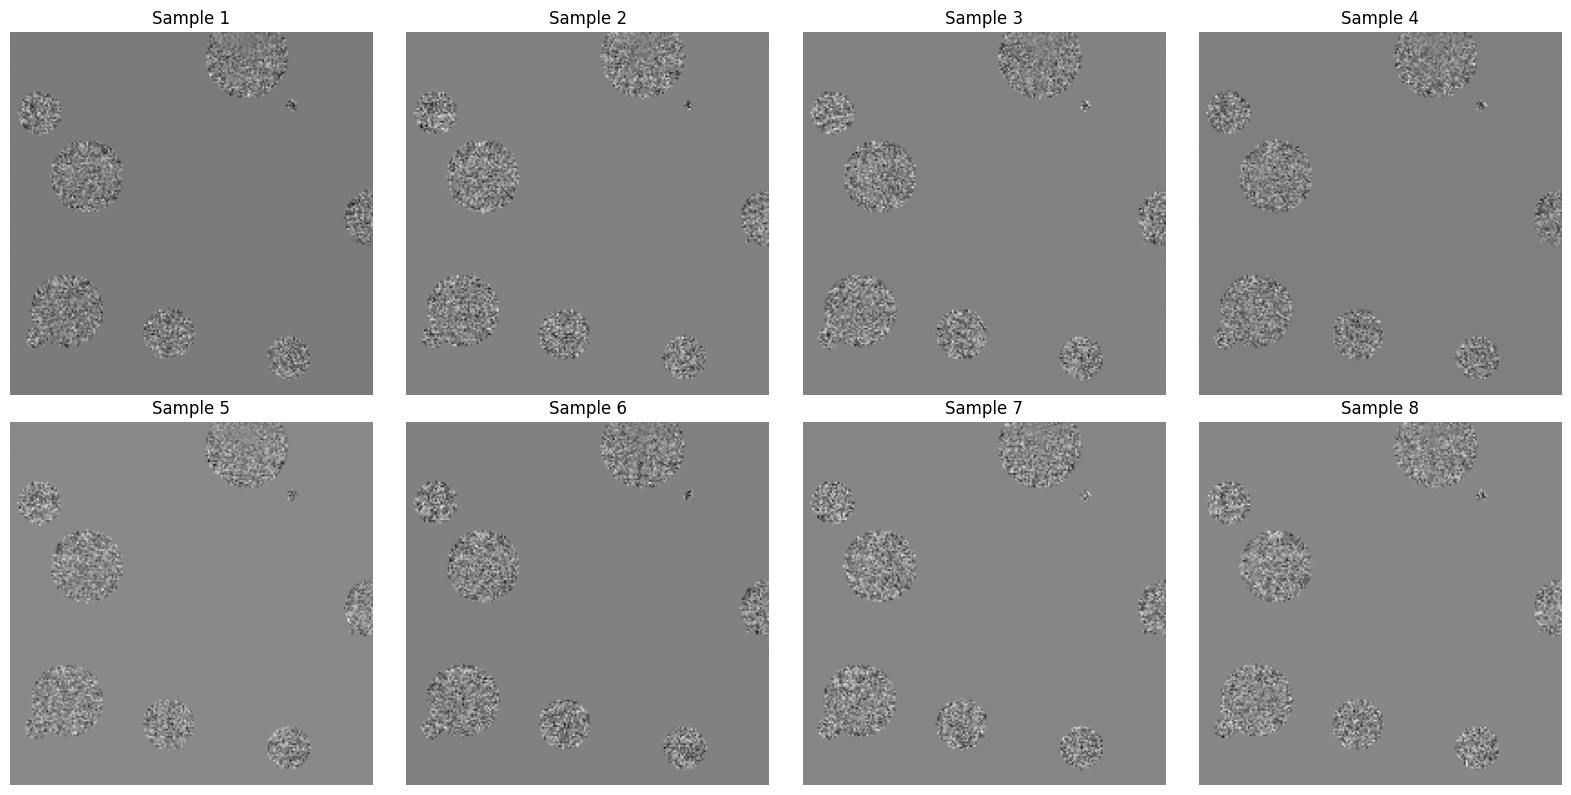

In [20]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.optimize import minimize


# ============================================================
# Basic helpers
# ============================================================

def _infer_mask(image, mask_missing=None):
    image = np.asarray(image, dtype=float)
    if image.ndim != 2:
        raise ValueError("Expected a 2D grayscale image.")
    if mask_missing is None:
        mask_missing = ~np.isfinite(image)
    else:
        mask_missing = np.asarray(mask_missing, dtype=bool)
        if mask_missing.shape != image.shape:
            raise ValueError("mask_missing must have the same shape as image.")
    valid_mask = ~mask_missing
    if valid_mask.sum() == 0:
        raise ValueError("No observed pixels available.")
    return image, mask_missing, valid_mask


def _normalize_observed(image, valid_mask):
    image_fill = image.copy()
    obs_mean = np.nanmean(image_fill[valid_mask])
    image_fill[~valid_mask] = obs_mean

    mu = float(np.mean(image_fill[valid_mask]))
    sigma = float(np.std(image_fill[valid_mask]))
    if sigma < 1e-8:
        sigma = 1.0

    image_norm = (image_fill - mu) / sigma
    return image_fill, image_norm, mu, sigma


def _signed_ky(ky_idx, H):
    return ky_idx if ky_idx <= H // 2 else ky_idx - H


def _base_phase(H, W, ky_idx, kx_idx):
    ky = _signed_ky(ky_idx, H)
    yy, xx = np.meshgrid(np.arange(H), np.arange(W), indexing="ij")
    return 2.0 * np.pi * (ky * yy / H + kx_idx * xx / W)


def _fft_peak_candidates(image_norm, valid_mask, max_modes=3, known_peak_coords=None):
    H, W = image_norm.shape
    x0 = np.zeros_like(image_norm)
    x0[valid_mask] = image_norm[valid_mask]
    spec = np.fft.rfft2(x0)
    mag = np.abs(spec)
    mag[0, 0] = 0.0

    freq_list = []

    if known_peak_coords is not None:
        for ky, kx in known_peak_coords:
            ky = int(ky)
            kx = int(kx)
            if 0 <= ky < H and 0 <= kx <= W // 2 and (ky, kx) != (0, 0):
                if (ky, kx) not in freq_list:
                    freq_list.append((ky, kx))

    flat_idx = np.argsort(mag.ravel())[::-1]
    for idx in flat_idx:
        ky, kx = np.unravel_index(idx, mag.shape)
        if (ky, kx) == (0, 0):
            continue
        if (ky, kx) not in freq_list:
            freq_list.append((ky, kx))
        if len(freq_list) >= (len(known_peak_coords) if known_peak_coords else 0) + max_modes:
            break

    return freq_list


def _unwrap2d(phi):
    return np.unwrap(np.unwrap(phi, axis=0), axis=1)


def _softplus(x):
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0.0)


def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def _inv_softplus(y):
    y = np.maximum(y, 1e-10)
    return np.where(y > 20, y, np.log(np.expm1(y)))


# ============================================================
# Discrete differential operators
# ============================================================

def _grad_x(f):
    return f[:, 1:] - f[:, :-1]


def _grad_y(f):
    return f[1:, :] - f[:-1, :]


def _div_from_edges(px, py):
    """
    Adjoint of forward differences.
    px: H x (W-1)
    py: (H-1) x W
    """
    H = py.shape[0] + 1
    W = px.shape[1] + 1
    out = np.zeros((H, W), dtype=float)

    # horizontal
    out[:, :-1] -= px
    out[:, 1:] += px

    # vertical
    out[:-1, :] -= py
    out[1:, :] += py

    return out


def _quad_smooth_value_grad(f):
    """
    0.5 * sum_edges (df)^2
    """
    dx = _grad_x(f)
    dy = _grad_y(f)
    value = 0.5 * (np.sum(dx**2) + np.sum(dy**2))
    grad = -_div_from_edges(dx, dy)
    return value, grad


def _grid_degree(H, W):
    deg = np.zeros((H, W), dtype=float)
    deg[:, :-1] += 1
    deg[:, 1:] += 1
    deg[:-1, :] += 1
    deg[1:, :] += 1
    return deg


def _tv_weighted_value_grad(phi, wx, wy, eps=1e-3):
    """
    Smoothed anisotropic weighted TV:
      sum sqrt((wx * dphi_x)^2 + eps^2) + sum sqrt((wy * dphi_y)^2 + eps^2)

    wx: H x (W-1)
    wy: (H-1) x W
    """
    dx = _grad_x(phi)
    dy = _grad_y(phi)

    denx = np.sqrt((wx * dx)**2 + eps**2)
    deny = np.sqrt((wy * dy)**2 + eps**2)

    value = np.sum(denx) + np.sum(deny)

    px = (wx**2) * dx / denx
    py = (wy**2) * dy / deny

    grad = -_div_from_edges(px, py)

    # diagonal Hessian approximation contribution per pixel
    cx = (wx**2) / denx
    cy = (wy**2) / deny

    hdiag = np.zeros_like(phi)
    hdiag[:, :-1] += cx
    hdiag[:, 1:] += cx
    hdiag[:-1, :] += cy
    hdiag[1:, :] += cy

    return value, grad, hdiag


# ============================================================
# Initialization by local demodulation
# ============================================================

def _initialize_fields(
    image_norm,
    valid_mask,
    freq_list,
    init_sigma=5.0,
    amp_floor=1e-3
):
    H, W = image_norm.shape
    maskf = valid_mask.astype(float)
    denom = gaussian_filter(maskf, init_sigma) + 1e-8

    # smooth background init
    b0 = gaussian_filter(image_norm * maskf, init_sigma) / denom

    residual = image_norm - b0

    A0_list = []
    phi0_list = []
    weight_x_list = []
    weight_y_list = []
    base_phase_list = []

    for ky_idx, kx_idx in freq_list:
        phase0 = _base_phase(H, W, ky_idx, kx_idx)
        base_phase_list.append(phase0)

        # local lock-in demodulation
        U0 = 2.0 * gaussian_filter(maskf * residual * np.cos(phase0), init_sigma) / denom
        V0 = -2.0 * gaussian_filter(maskf * residual * np.sin(phase0), init_sigma) / denom

        A0 = np.sqrt(U0**2 + V0**2) + amp_floor
        phi0 = _unwrap2d(np.arctan2(V0, U0))

        # subtract current mode contribution from residual for next mode
        residual = residual - A0 * np.cos(phase0 + phi0)

        # fixed weights for phase TV
        wx = 0.5 * (A0[:, 1:] + A0[:, :-1])
        wy = 0.5 * (A0[1:, :] + A0[:-1, :])

        scale = np.percentile(A0, 90) + 1e-8
        wx = np.clip(wx / scale, 0.05, 3.0)
        wy = np.clip(wy / scale, 0.05, 3.0)

        A0_list.append(A0)
        phi0_list.append(phi0)
        weight_x_list.append(wx)
        weight_y_list.append(wy)

    return b0, A0_list, phi0_list, weight_x_list, weight_y_list, base_phase_list


# ============================================================
# Packing / unpacking
# ============================================================

def _pack_params(b, s_list, phi_list):
    arrs = [b.ravel()]
    for s in s_list:
        arrs.append(s.ravel())
    for phi in phi_list:
        arrs.append(phi.ravel())
    return np.concatenate(arrs)


def _unpack_params(theta, H, W, M):
    N = H * W
    idx = 0

    b = theta[idx:idx+N].reshape(H, W)
    idx += N

    s_list = []
    for _ in range(M):
        s_list.append(theta[idx:idx+N].reshape(H, W))
        idx += N

    phi_list = []
    for _ in range(M):
        phi_list.append(theta[idx:idx+N].reshape(H, W))
        idx += N

    return b, s_list, phi_list


# ============================================================
# Main reconstruction
# ============================================================

def phase_field_apb_reconstruct(
    image_occlude,
    mask_missing=None,
    max_modes=3,
    known_peak_coords=None,
    init_sigma=5.0,
    noise_std=0.08,
    amp_floor=1e-3,
    # priors
    lambda_b=1.0,
    lambda_A=0.5,
    lambda_phi_smooth=0.05,
    lambda_phi_tv=0.4,
    tv_eps=1e-3,
    # optimizer
    maxiter=150,
    gtol=1e-6,
    ftol=1e-9,
    # behavior
    enforce_observed_pixels=False,
    clip_to_observed_range=False,
    verbose=True
):
    """
    APB-aware local phase-field reconstruction.

    Returns
    -------
    recon : 2D ndarray
        MAP reconstruction
    unc : 2D ndarray
        Approximate posterior std (diagonal Laplace / Gauss-Newton)
    info : dict
        Full parameter access and diagnostic objects
    """
    image, mask_missing, valid_mask = _infer_mask(image_occlude, mask_missing)
    H, W = image.shape
    Mmask = valid_mask.astype(float)

    image_fill, image_norm, obs_mu, obs_sigma = _normalize_observed(image, valid_mask)

    freq_list = _fft_peak_candidates(
        image_norm=image_norm,
        valid_mask=valid_mask,
        max_modes=max_modes,
        known_peak_coords=known_peak_coords
    )

    b0, A0_list, phi0_list, wx_list, wy_list, base_phase_list = _initialize_fields(
        image_norm=image_norm,
        valid_mask=valid_mask,
        freq_list=freq_list,
        init_sigma=init_sigma,
        amp_floor=amp_floor
    )

    # parameterize A by softplus(s) + amp_floor
    s0_list = [_inv_softplus(np.maximum(A0 - amp_floor, 1e-8)) for A0 in A0_list]
    theta0 = _pack_params(b0, s0_list, phi0_list)

    deg = _grid_degree(H, W)
    noise_var = noise_std ** 2
    num_modes = len(freq_list)

    history = []

    def objective_and_grad(theta):
        b, s_list, phi_list = _unpack_params(theta, H, W, num_modes)

        A_list = [_softplus(s) + amp_floor for s in s_list]
        dA_ds_list = [_sigmoid(s) for s in s_list]

        pred = b.copy()
        total_phase_list = []
        cos_list = []
        sin_list = []

        for m in range(num_modes):
            total_phase = base_phase_list[m] + phi_list[m]
            c = np.cos(total_phase)
            s = np.sin(total_phase)

            pred = pred + A_list[m] * c

            total_phase_list.append(total_phase)
            cos_list.append(c)
            sin_list.append(s)

        resid = Mmask * (pred - image_norm)
        data_val = 0.5 * np.sum(resid**2) / noise_var
        common = resid / noise_var

        # background
        val_b, grad_b_prior = _quad_smooth_value_grad(b)
        obj = data_val + lambda_b * val_b
        grad_b = common + lambda_b * grad_b_prior

        grad_s_list = []
        grad_phi_list = []

        for m in range(num_modes):
            A = A_list[m]
            dA_ds = dA_ds_list[m]
            c = cos_list[m]
            s = sin_list[m]

            # data term
            grad_A_data = common * c
            grad_phi_data = common * (-A * s)

            # amplitude smoothness
            val_A, grad_A_prior = _quad_smooth_value_grad(A)

            # phase smoothness
            val_phi_sm, grad_phi_sm = _quad_smooth_value_grad(phi_list[m])

            # phase TV with fixed weights from initialization
            val_phi_tv, grad_phi_tv, _ = _tv_weighted_value_grad(
                phi_list[m], wx_list[m], wy_list[m], eps=tv_eps
            )

            obj += lambda_A * val_A
            obj += lambda_phi_smooth * val_phi_sm
            obj += lambda_phi_tv * val_phi_tv

            grad_A = grad_A_data + lambda_A * grad_A_prior
            grad_s = grad_A * dA_ds

            grad_phi = (
                grad_phi_data
                + lambda_phi_smooth * grad_phi_sm
                + lambda_phi_tv * grad_phi_tv
            )

            grad_s_list.append(grad_s)
            grad_phi_list.append(grad_phi)

        grad = _pack_params(grad_b, grad_s_list, grad_phi_list)
        return obj, grad

    def callback(theta):
        obj, _ = objective_and_grad(theta)
        history.append(float(obj))
        if verbose:
            print(f"Iter {len(history):03d} | objective = {obj:.6f}")

    result = minimize(
        objective_and_grad,
        theta0,
        method="L-BFGS-B",
        jac=True,
        callback=callback,
        options={
            "maxiter": maxiter,
            "gtol": gtol,
            "ftol": ftol,
            "disp": verbose,
        }
    )

    theta_map = result.x
    b_map, s_map_list, phi_map_list = _unpack_params(theta_map, H, W, num_modes)
    A_map_list = [_softplus(s) + amp_floor for s in s_map_list]
    dA_ds_map_list = [_sigmoid(s) for s in s_map_list]

    pred_norm = b_map.copy()
    cos_map_list = []
    sin_map_list = []

    for m in range(num_modes):
        total_phase = base_phase_list[m] + phi_map_list[m]
        c = np.cos(total_phase)
        s = np.sin(total_phase)
        pred_norm = pred_norm + A_map_list[m] * c
        cos_map_list.append(c)
        sin_map_list.append(s)

    # --------------------------------------------------------
    # Diagonal Laplace / Gauss-Newton uncertainty approximation
    # --------------------------------------------------------
    # This is approximate: it ignores cross-covariances.
    hdiag_b = Mmask / noise_var + lambda_b * deg + 1e-8
    var_b = 1.0 / hdiag_b

    var_s_list = []
    var_phi_list = []

    for m in range(num_modes):
        A = A_map_list[m]
        dA_ds = dA_ds_map_list[m]
        c = cos_map_list[m]
        s = sin_map_list[m]

        # amplitude diagonal curvature
        hdiag_s = (
            Mmask * (dA_ds * c)**2 / noise_var
            + lambda_A * deg * (dA_ds**2)
            + 1e-8
        )
        var_s = 1.0 / hdiag_s

        # phase diagonal curvature
        _, _, hdiag_phi_tv = _tv_weighted_value_grad(
            phi_map_list[m], wx_list[m], wy_list[m], eps=tv_eps
        )
        hdiag_phi = (
            Mmask * (A * s)**2 / noise_var
            + lambda_phi_smooth * deg
            + lambda_phi_tv * hdiag_phi_tv
            + 1e-8
        )
        var_phi = 1.0 / hdiag_phi

        var_s_list.append(var_s)
        var_phi_list.append(var_phi)

    # propagate to image variance
    var_pred_norm = var_b.copy()
    for m in range(num_modes):
        dA_ds = dA_ds_map_list[m]
        A = A_map_list[m]
        c = cos_map_list[m]
        s = sin_map_list[m]

        var_pred_norm = (
            var_pred_norm
            + (dA_ds * c)**2 * var_s_list[m]
            + (A * s)**2 * var_phi_list[m]
        )

    var_pred_norm = np.maximum(var_pred_norm, 0.0)

    recon = pred_norm * obs_sigma + obs_mu
    unc = np.sqrt(var_pred_norm) * obs_sigma

    if np.any(mask_missing) and enforce_observed_pixels:
        recon[valid_mask] = image_fill[valid_mask]
        unc[valid_mask] = 0.0

    if clip_to_observed_range:
        vmin = np.nanmin(image_fill[valid_mask])
        vmax = np.nanmax(image_fill[valid_mask])
        recon = np.clip(recon, vmin, vmax)

    info = {
        "image_shape": (H, W),
        "image_fill": image_fill,
        "image_norm": image_norm,
        "mask_missing": mask_missing,
        "valid_mask": valid_mask,
        "obs_mu": obs_mu,
        "obs_sigma": obs_sigma,
        "freq_list_rfft": freq_list,
        "base_phase_list": base_phase_list,
        # MAP fields
        "b_map": b_map,
        "A_map_list": A_map_list,
        "phi_map_list": phi_map_list,
        "s_map_list": s_map_list,
        "recon_mean_norm": pred_norm,
        "recon_var_norm": var_pred_norm,
        # uncertainty
        "var_b": var_b,
        "var_s_list": var_s_list,
        "var_phi_list": var_phi_list,
        # initialization / prior weights
        "wx_list": wx_list,
        "wy_list": wy_list,
        "init_b": b0,
        "init_A_list": A0_list,
        "init_phi_list": phi0_list,
        # optimizer
        "theta_map": theta_map,
        "result": result,
        "objective_history": history,
        # settings
        "settings": {
            "max_modes": max_modes,
            "known_peak_coords": known_peak_coords,
            "init_sigma": init_sigma,
            "noise_std": noise_std,
            "amp_floor": amp_floor,
            "lambda_b": lambda_b,
            "lambda_A": lambda_A,
            "lambda_phi_smooth": lambda_phi_smooth,
            "lambda_phi_tv": lambda_phi_tv,
            "tv_eps": tv_eps,
        }
    }

    return recon, unc, info


# ============================================================
# Derived fields and uncertainty
# ============================================================

def extract_phase_mode_fields(info, mode_index=0):
    A = info["A_map_list"][mode_index]
    phi = info["phi_map_list"][mode_index]
    A_std = np.sqrt(np.maximum(info["var_s_list"][mode_index], 0.0)) * _sigmoid(info["s_map_list"][mode_index])
    phi_std = np.sqrt(np.maximum(info["var_phi_list"][mode_index], 0.0))

    gy, gx = np.gradient(phi)
    phase_grad_mag = np.sqrt(gx**2 + gy**2)

    return {
        "A_mean": A,
        "A_std": A_std,
        "phi_mean": phi,
        "phi_std": phi_std,
        "phase_grad_mag": phase_grad_mag,
        "freq_rfft": info["freq_list_rfft"][mode_index],
    }


def sample_phase_field_posterior(info, n_samples=8, random_state=0, enforce_observed=True):
    """
    Diagonal Laplace approximation sampling in parameter space.
    """
    rng = np.random.default_rng(random_state)

    H, W = info["image_shape"]
    valid_mask = info["valid_mask"]
    mask_missing = info["mask_missing"]
    image_fill = info["image_fill"]
    obs_mu = info["obs_mu"]
    obs_sigma = info["obs_sigma"]

    num_modes = len(info["freq_list_rfft"])

    samples = []

    for _ in range(n_samples):
        b_s = info["b_map"] + np.sqrt(info["var_b"]) * rng.standard_normal((H, W))

        pred = b_s.copy()

        for m in range(num_modes):
            s_mean = info["s_map_list"][m]
            s_std = np.sqrt(np.maximum(info["var_s_list"][m], 0.0))
            phi_mean = info["phi_map_list"][m]
            phi_std = np.sqrt(np.maximum(info["var_phi_list"][m], 0.0))

            s_s = s_mean + s_std * rng.standard_normal((H, W))
            phi_s = phi_mean + phi_std * rng.standard_normal((H, W))

            A_s = _softplus(s_s) + info["settings"]["amp_floor"]
            phase = info["base_phase_list"][m] + phi_s
            pred = pred + A_s * np.cos(phase)

        x_s = pred * obs_sigma + obs_mu

        if np.any(mask_missing) and enforce_observed:
            x_s[valid_mask] = image_fill[valid_mask]

        samples.append(x_s)

    return np.asarray(samples)


# ============================================================
# Visualization
# ============================================================

def plot_phase_field_summary(image_occlude, recon, unc, info, mode_index=0):
    mode = extract_phase_mode_fields(info, mode_index=mode_index)

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))

    axes[0, 0].imshow(image_occlude, cmap="gray")
    axes[0, 0].set_title("Input")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(recon, cmap="gray")
    axes[0, 1].set_title("MAP reconstruction")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(unc, cmap="magma")
    axes[0, 2].set_title("Approx. posterior std")
    axes[0, 2].axis("off")

    axes[0, 3].imshow(info["b_map"], cmap="gray")
    axes[0, 3].set_title("Background field (normalized)")
    axes[0, 3].axis("off")

    axes[1, 0].imshow(mode["A_mean"], cmap="viridis")
    axes[1, 0].set_title(f"Mode {mode_index}: amplitude")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(mode["phi_mean"], cmap="twilight")
    axes[1, 1].set_title(f"Mode {mode_index}: phase")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(mode["phi_std"], cmap="magma")
    axes[1, 2].set_title(f"Mode {mode_index}: phase std")
    axes[1, 2].axis("off")

    axes[1, 3].imshow(mode["phase_grad_mag"], cmap="inferno")
    axes[1, 3].set_title(f"Mode {mode_index}: |grad phase|")
    axes[1, 3].axis("off")

    plt.tight_layout()
    plt.show()


def plot_objective_history(info):
    hist = info["objective_history"]
    if len(hist) == 0:
        print("No callback history stored.")
        return

    plt.figure(figsize=(7, 4))
    plt.plot(hist, marker="o")
    plt.xlabel("Optimizer callback step")
    plt.ylabel("Objective")
    plt.title("MAP objective history")
    plt.tight_layout()
    plt.show()


def plot_posterior_samples(samples, ncols=4):
    n = samples.shape[0]
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i in range(n):
        axes[i].imshow(samples[i], cmap="gray")
        axes[i].set_title(f"Sample {i+1}")
        axes[i].axis("off")

    for i in range(n, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# Example usage
# ============================================================


recon, unc, info = phase_field_apb_reconstruct(
    image_occlude,
    mask_missing=mask_missing,          # infer from NaNs
    max_modes=824,
    known_peak_coords=None,     # or [(ky1, kx1), (ky2, kx2)]
    init_sigma=5.0,
    noise_std=0.008,
    lambda_b=1.0,
    lambda_A=0.5,
    lambda_phi_smooth=0.05,
    lambda_phi_tv=0.4,
    tv_eps=1e-4,
    maxiter=150,
    verbose=True
)

plot_phase_field_summary(image_occlude, recon, unc, info, mode_index=0)
plot_objective_history(info)

mode0 = extract_phase_mode_fields(info, mode_index=0)
phi_mean = mode0["phi_mean"]
phi_std = mode0["phi_std"]

samples = sample_phase_field_posterior(info, n_samples=8, random_state=0)
plot_posterior_samples(samples)